Starting hyperparameter optimization...


LML: -125.77: 100%|██████████| 1000/1000 [00:02<00:00, 365.83it/s]



--- Optimized Hyperparameters ---
Kernel Lengthscale: 0.114
Kernel Variance: 1.803
Likelihood Sigma: 0.086
---------------------------------


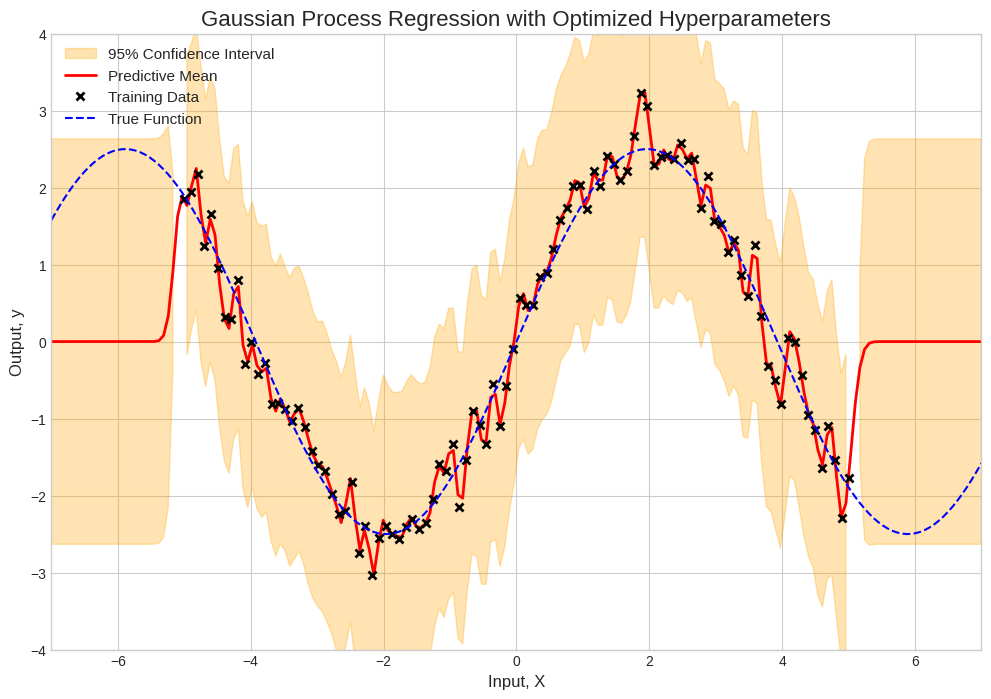

In [3]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import norm
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class GPRegression(nn.Module):
    """
    Implements a standard Gaussian Process (GP) regression model.

    The model assumes:
    - A Gaussian Process prior over the latent function f.
    - A Gaussian likelihood for the observations y.

    This model is analytically tractable. Hyperparameters are optimized by
    maximizing the log marginal likelihood.
    """
    def __init__(self, X, y, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter, so we register it as a buffer.
        self.register_buffer('X', X)
        self.register_buffer('y', y)
        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter ---
        # Hyperparameters are stored in log-space to ensure they remain positive
        # during optimization.
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        # We optimize the log of the noise *variance* (sigma^2)
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        return lengthscale, variance, sigma_sq

    def kernel(self, A, B):
        """
        Squared Exponential (RBF) kernel.
        k(x, x') = σ_f^2 * exp(-0.5 * ||x - x'||^2 / l^2)
        """
        lengthscale, variance, _ = self._get_hyperparams()
        # Use torch.cdist for efficiently computing pairwise distances
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def log_marginal_likelihood(self):
        """
        Calculates the log marginal likelihood (LML) of the GP model.
        LML = -0.5 * y^T * K_y^-1 * y - 0.5 * log|K_y| - 0.5 * N * log(2π)
        See Rasmussen and Williams (2006), Eq. 2.30.
        """
        _, _, sigma_sq = self._get_hyperparams()

        # Build the full covariance matrix for the noisy observations y
        K = self.kernel(self.X, self.X)
        K_y = K + sigma_sq * torch.eye(self.N)

        # Use Cholesky decomposition for numerical stability and efficiency
        # L L^T = K_y
        L = torch.linalg.cholesky(K_y)

        # Calculate log|K_y| = 2 * sum(log(diag(L)))
        log_det_K_y = 2 * torch.sum(torch.log(torch.diag(L)))

        # Calculate y^T * K_y^-1 * y using the Cholesky factor
        # First solve L * alpha = y for alpha, then y^T * K_y^-1 * y = alpha^T * alpha
        alpha = torch.cholesky_solve(self.y, L)
        y_invK_y = torch.sum(self.y * alpha)

        # The final log marginal likelihood
        lml = -0.5 * y_invK_y - 0.5 * log_det_K_y - 0.5 * self.N * math.log(2 * math.pi)
        return lml

    def fit(self, max_iter=200, lr=0.01):
        """
        Fits the model by maximizing the log marginal likelihood with respect
        to the hyperparameters.
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        print("Starting hyperparameter optimization...")
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            optimizer.zero_grad()
            # We want to maximize the LML, so we minimize its negative
            loss = -self.log_marginal_likelihood()
            loss.backward()
            optimizer.step()
            pbar.set_description(f"LML: {-loss.item():.2f}")

    def predict(self, X_test):
        """
        Make predictions for new test data X_test.
        See Rasmussen and Williams (2006), Eqs. 2.25 & 2.26.
        """
        # Ensure we are not tracking gradients for prediction
        with torch.no_grad():
            _, _, sigma_sq = self._get_hyperparams()

            # Precompute K_y and its Cholesky decomposition
            K = self.kernel(self.X, self.X)
            K_y = K + sigma_sq * torch.eye(self.N)
            L = torch.linalg.cholesky(K_y)

            # Covariance between test and training points
            K_star = self.kernel(self.X, X_test)

            # Predictive mean: f_* = K_*^T * K_y^-1 * y
            alpha = torch.cholesky_solve(self.y, L)
            pred_mean = K_star.T @ alpha

            # Predictive variance: V[f_*] = k(x_*, x_*) - K_*^T * K_y^-1 * K_*
            v = torch.cholesky_solve(K_star, L)
            pred_var = self.kernel(X_test, X_test).diag() - torch.sum(v * v, dim=0)

            return pred_mean, pred_var.unsqueeze(1)


if __name__ == '__main__':
    # 1. Generate synthetic data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train * 0.8) * 2.5
    noise = torch.randn(N, 1) * 0.3 # Gaussian noise
    y_train = y_true + noise

    # 2. Setup and fit the model
    model = GPRegression(
        X=X_train,
        y=y_train,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=0.05
    )
    model.fit(max_iter=1000, lr=0.01)

    # Print final optimized hyperparameters
    l_final, var_final, sigma_sq_final = model._get_hyperparams()
    print("\n--- Optimized Hyperparameters ---")
    print(f"Kernel Lengthscale: {l_final.item():.3f}")
    print(f"Kernel Variance: {var_final.item():.3f}")
    print(f"Likelihood Sigma: {torch.sqrt(sigma_sq_final).item():.3f}")
    print("---------------------------------")


    # 3. Make predictions
    X_test = torch.linspace(-7, 7, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # 4. Visualize the results
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 8))

    # Calculate the 95% confidence interval (z=1.96 for Gaussian)
    pred_std = torch.sqrt(pred_var)
    lower = pred_mean - 1.96 * pred_std
    upper = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data')
    plt.plot(X_test, torch.sin(X_test * 0.8) * 2.5, 'b--', label='True Function')


    plt.title('Gaussian Process Regression with Optimized Hyperparameters', fontsize=16)
    plt.xlabel('Input, X', fontsize=12)
    plt.ylabel('Output, y', fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.xlim(-7, 7)
    plt.ylim(-4, 4)
    plt.show()

# GPR with Student-t likelihood

2025-07-02 15:41:29.890859: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-02 15:41:29.897493: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751438489.906314   30168 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751438489.909015   30168 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751438489.915895   30168 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

--- 1. Training GPR (Gaussian Noise) ---
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │      value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 12.0994    │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │  2.85612   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │  0.0810755 │
╘═════════════════════════╧════

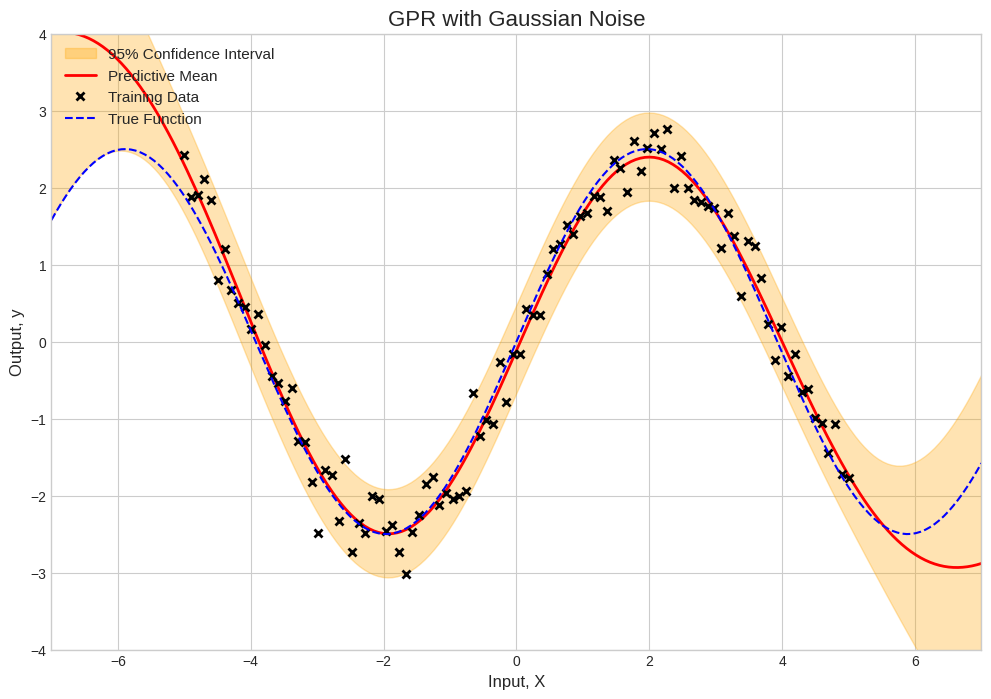


--- 2. Training VGP (Student-t Noise) ---
╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                                │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════════════════════════════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 11.13414                                             │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────────────────────────────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 2.80639                     

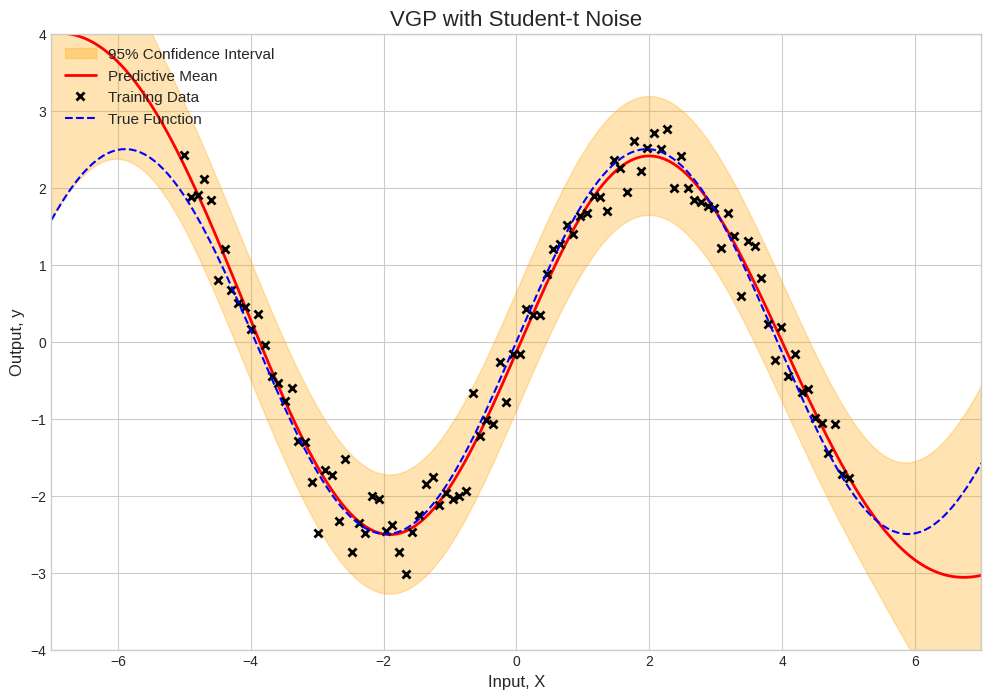


--- 3. Training SGPR (Gaussian Noise) ---
╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value               │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════╡
│ SGPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 12.09953            │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────┤
│ SGPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 2.85613             │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────┤
│ SGPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True 

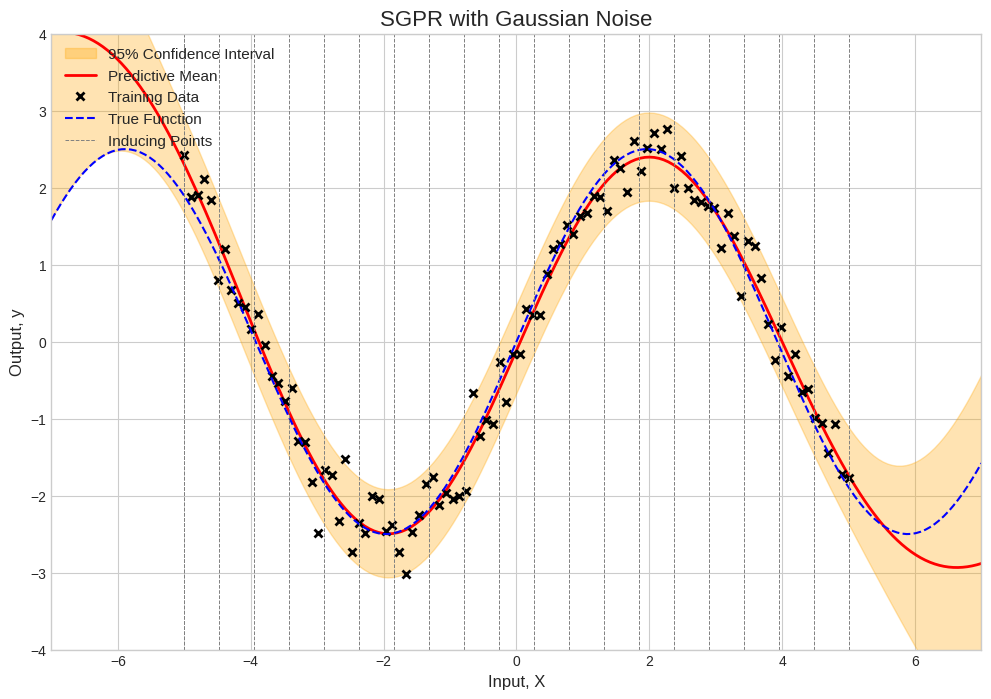


--- 4. Training SVGP (Student-t Noise) ---
╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value                                                │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════════════════════════════════════════╡
│ SVGP.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 11.61569                                             │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────────────────────────────────────────┤
│ SVGP.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 2.82394                          

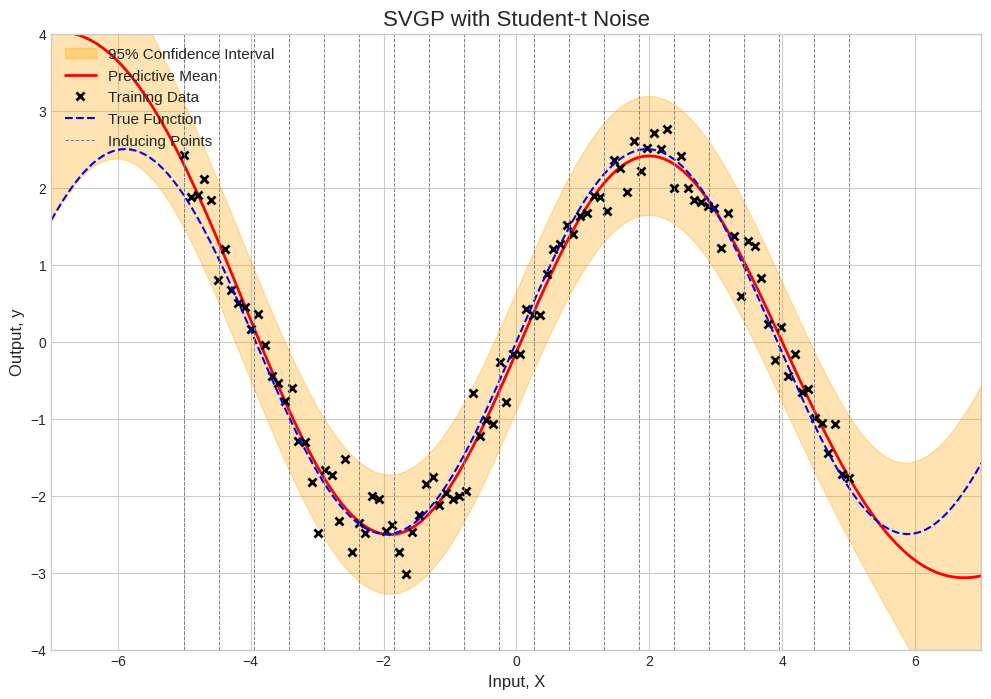

In [4]:
import numpy as np
import tensorflow as tf
import gpflow
import matplotlib.pyplot as plt

# 再現性のためのシード設定
np.random.seed(0)
tf.random.set_seed(0)

# Matplotlibのスタイル設定
plt.style.use('seaborn-v0_8-whitegrid')

# --------------------------------------------------------------------------
# 1. 合成データの生成 (元コードと同様)
# --------------------------------------------------------------------------
N = 100
X_train = np.linspace(-5, 5, N).reshape(-1, 1)
y_true = np.sin(X_train * 0.8) * 2.5
noise = np.random.randn(N, 1) * 0.3 # ガウスノイズ
y_train = y_true + noise

# GPflowで使いやすいようにタプルにまとめる
data = (tf.convert_to_tensor(X_train, dtype=tf.float64), 
        tf.convert_to_tensor(y_train, dtype=tf.float64))

# 予測用のテストデータ
X_test = np.linspace(-7, 7, 200).reshape(-1, 1)


# --------------------------------------------------------------------------
# 2. 結果をプロットするためのヘルパー関数
# --------------------------------------------------------------------------
def plot_result(model, title, inducing_points=None):
    """ガウス過程モデルの予測結果をプロットする関数"""
    mean, var = model.predict_y(X_test)
    std = tf.sqrt(var)

    plt.figure(figsize=(12, 8))
    
    # 95%信頼区間
    plt.fill_between(
        X_test.flatten(),
        (mean - 1.96 * std).numpy().flatten(),
        (mean + 1.96 * std).numpy().flatten(),
        color='orange',
        alpha=0.3,
        label='95% Confidence Interval'
    )
    # 予測平均、学習データ、真の関数
    plt.plot(X_test, mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data')
    plt.plot(X_test, np.sin(X_test * 0.8) * 2.5, 'b--', label='True Function')

    # 誘導点（もしあれば）をプロット
    if inducing_points is not None:
        # 誘導点の位置を縦の破線で示す
        for z_val in inducing_points.numpy().flatten():
            plt.axvline(x=z_val, color='gray', linestyle='--', linewidth=0.7)
        # 凡例用に1本だけラベル付きで描画
        plt.axvline(x=inducing_points.numpy().flatten()[0], color='gray', linestyle='--', linewidth=0.7, label='Inducing Points')

    plt.title(title, fontsize=16)
    plt.xlabel('Input, X', fontsize=12)
    plt.ylabel('Output, y', fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.xlim(-7, 7)
    plt.ylim(-4, 4)
    plt.show()

# --------------------------------------------------------------------------
# 3. 各モデルのセットアップ、学習、可視化
# --------------------------------------------------------------------------

# --- モデル 1: GPR (i.i.d. Gaussian noise) ---
print("--- 1. Training GPR (Gaussian Noise) ---")
# RBFカーネル (Squared Exponential)
kernel_gpr = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)

# GPRモデルの定義
# ガウス尤度はモデルに組み込まれている
model_gpr = gpflow.models.GPR(data=data, kernel=kernel_gpr)

# ハイパーパラメータの最適化
optimizer = gpflow.optimizers.Scipy()
optimizer.minimize(model_gpr.training_loss, model_gpr.trainable_variables, options=dict(maxiter=1000))

# 最適化されたハイパーパラメータの表示
gpflow.utilities.print_summary(model_gpr)
plot_result(model_gpr, 'GPR with Gaussian Noise')


# --- モデル 2: VGP (Student-t noise) ---
print("\n--- 2. Training VGP (Student-t Noise) ---")
kernel_vgp = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
# スチューデントのt分布尤度
likelihood_vgp = gpflow.likelihoods.StudentT(scale=0.1, df=3.0) # df: 自由度

# VGPモデルの定義 (変分推論を使用)
model_vgp = gpflow.models.VGP(data=data, kernel=kernel_vgp, likelihood=likelihood_vgp, num_latent_gps=1)

# 最適化
optimizer.minimize(model_vgp.training_loss, model_vgp.trainable_variables, options=dict(maxiter=1000))

gpflow.utilities.print_summary(model_vgp)
plot_result(model_vgp, 'VGP with Student-t Noise')


# --- モデル 3: SGPR (i.i.d. Gaussian noise) ---
print("\n--- 3. Training SGPR (Gaussian Noise) ---")
# 誘導点 (Inducing Points) の設定
M = 20  # 誘導点の数
inducing_points_sgpr = tf.constant(np.linspace(-5, 5, M).reshape(-1, 1), dtype=tf.float64)

kernel_sgpr = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)

# SGPRモデルの定義
model_sgpr = gpflow.models.SGPR(
    data=data, 
    kernel=kernel_sgpr, 
    inducing_variable=inducing_points_sgpr
)

# 最適化
optimizer.minimize(model_sgpr.training_loss, model_sgpr.trainable_variables, options=dict(maxiter=1000))

gpflow.utilities.print_summary(model_sgpr)
plot_result(model_sgpr, 'SGPR with Gaussian Noise', inducing_points=inducing_points_sgpr)


# --- モデル 4: SVGP (Student-t noise) ---
print("\n--- 4. Training SVGP (Student-t Noise) ---")
# 誘導点 (SGPRと同じものを使用)
inducing_points_svgp = tf.constant(np.linspace(-5, 5, M).reshape(-1, 1), dtype=tf.float64)

kernel_svgp = gpflow.kernels.SquaredExponential(lengthscales=1.0, variance=1.0)
likelihood_svgp = gpflow.likelihoods.StudentT(scale=0.1, df=3.0)

# SVGPモデルの定義
model_svgp = gpflow.models.SVGP(
    kernel=kernel_svgp, 
    likelihood=likelihood_svgp, 
    inducing_variable=inducing_points_svgp,
    num_latent_gps=1
)

# SVGPの損失関数はデータを引数に取るため、クロージャでラップする
@tf.function
def training_loss_closure():
    return model_svgp.training_loss(data)

# 最適化
optimizer.minimize(training_loss_closure, model_svgp.trainable_variables, options=dict(maxiter=1000))

gpflow.utilities.print_summary(model_svgp)
plot_result(model_svgp, 'SVGP with Student-t Noise', inducing_points=inducing_points_svgp)

Starting optimization with hyperparameter AND inducing point updates...


  0%|          | 0/200 [00:00<?, ?it/s]

ELBO: -84.68: 100%|██████████| 200/200 [00:08<00:00, 23.35it/s]



--- Initial Z ---
[-5.         -4.47368431 -3.94736838 -3.42105246 -2.89473677 -2.36842108
 -1.84210515 -1.31578922 -0.78947353 -0.26315784  0.26315784  0.78947401
  1.3157897   1.84210539  2.36842155  2.89473724  3.42105293  3.94736862
  4.47368431  5.        ]

--- Optimized Z ---
[-5.86818512 -5.65509182 -5.1857651  -4.57246792 -3.90502009 -3.19782702
 -2.49513365 -1.78137463 -1.06647551 -0.35127214  0.36575337  1.08484526
  1.80174814  2.503431    3.21183285  3.92148395  4.58809382  5.20989401
  5.6793082   5.88335422]
-------------------


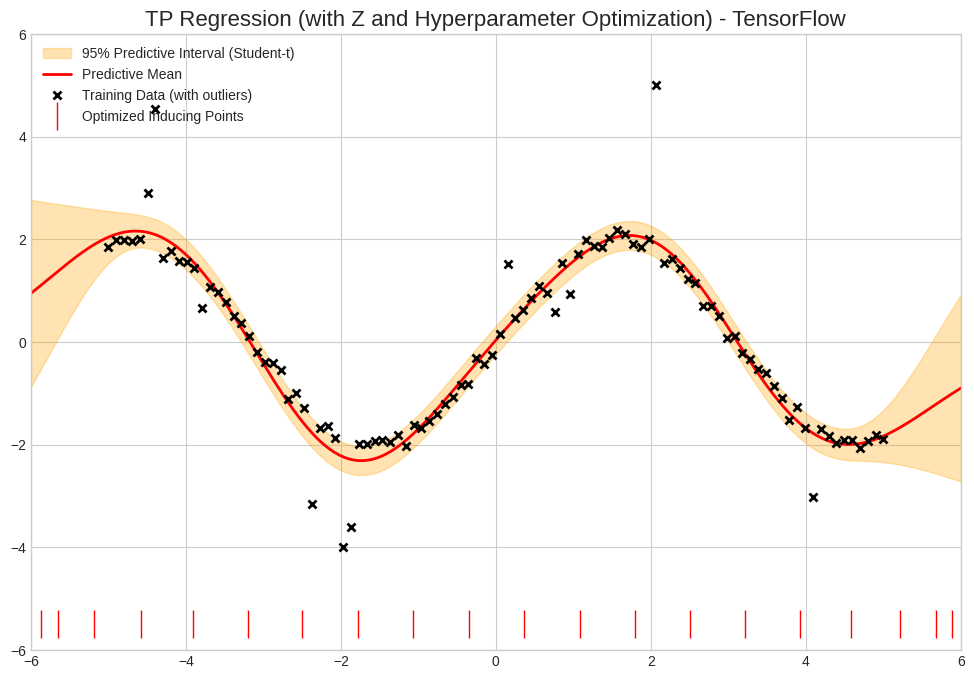

In [14]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
tf.keras.backend.set_floatx('float64')


class TPRegression(tf.keras.Model):
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data and model dimensions
        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # Data is not trainable
        self.X = tf.Variable(X, trainable=False, name="X_data")
        self.y = tf.Variable(y, trainable=False, name="y_data")

        # Z is a parameter to be optimized (trainable)
        self.Z = tf.Variable(Z_initial, trainable=True, name="Z_inducing_points")

        # Hyperparameters are trainable.
        self.log_kernel_lengthscale = tf.Variable(tf.math.log(tf.constant(kernel_lengthscale, dtype=tf.float64)), trainable=True, name="log_ls")
        self.log_kernel_variance = tf.Variable(tf.math.log(tf.constant(kernel_variance, dtype=tf.float64)), trainable=True, name="log_var")
        self.log_likelihood_sigma_sq = tf.Variable(tf.math.log(tf.constant(likelihood_sigma**2, dtype=tf.float64)), trainable=True, name="log_sigma_sq")
        self.log_nu_f = tf.Variable(tf.math.log(tf.constant(nu_f, dtype=tf.float64)), trainable=True, name="log_nu_f")
        self.log_nu_e = tf.Variable(tf.math.log(tf.constant(nu_e, dtype=tf.float64)), trainable=True, name="log_nu_e")

        # Manually collect trainable variables
        self.vars_to_train = [
            self.Z,
            self.log_kernel_lengthscale,
            self.log_kernel_variance,
            self.log_likelihood_sigma_sq,
            self.log_nu_f,
            self.log_nu_e
        ]

        # Variational Parameters (stateful, but not trained by optimizer)
        self.m_u = tf.Variable(tf.zeros((self.M, 1), dtype=tf.float64), trainable=False)
        self.L_u = tf.Variable(tf.eye(self.M, dtype=tf.float64), trainable=False)
        self.alpha_r = tf.Variable(1.0, trainable=False, dtype=tf.float64)
        self.beta_r = tf.Variable(1.0, trainable=False, dtype=tf.float64)
        self.alpha_lambda = tf.Variable(tf.ones((self.N, 1), dtype=tf.float64), trainable=False)
        self.beta_lambda = tf.Variable(tf.ones((self.N, 1), dtype=tf.float64), trainable=False)

    def _get_hyperparams(self):
        lengthscale = tf.math.exp(self.log_kernel_lengthscale)
        variance = tf.math.exp(self.log_kernel_variance)
        sigma_sq = tf.math.exp(self.log_likelihood_sigma_sq)
        nu_f = tf.math.exp(self.log_nu_f)
        nu_e = tf.math.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = tf.reduce_sum(tf.square(tf.expand_dims(A, 1) - tf.expand_dims(B, 0)), axis=2)
        return variance * tf.math.exp(-0.5 * sq_dist / tf.square(lengthscale))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        alpha_lambda_new = nu_e / 2.0 + 0.5
        expected_sq_error = tf.square(self.y - E_q_f) + Var_q_f
        beta_lambda_new = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error
        self.alpha_lambda.assign(tf.fill(self.alpha_lambda.shape, alpha_lambda_new))
        self.beta_lambda.assign(beta_lambda_new)

    def _update_q_r(self, E_quad_form_u):
        _, _, _, nu_f, _ = self._get_hyperparams()
        alpha_r_new = nu_f / 2.0 + self.M / 2.0
        beta_r_new = nu_f / 2.0 + 0.5 * tf.squeeze(E_quad_form_u)
        self.alpha_r.assign(alpha_r_new)
        self.beta_r.assign(beta_r_new)

    def _update_q_u(self, Kzz, Lzz, Kxz):
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda
        Psi = tf.matmul(tf.transpose(Kxz), (E_lambda * Kxz)) / sigma_sq
        B = E_r * Kzz + Psi
        L_B = tf.linalg.cholesky(B)
        Kzz_invB_Kzz = tf.linalg.cholesky_solve(L_B, Kzz)
        S_u = tf.matmul(Kzz, Kzz_invB_Kzz)
        S_u = 0.5 * (S_u + tf.transpose(S_u))
        self.L_u.assign(tf.linalg.cholesky(S_u + tf.eye(self.M, dtype=tf.float64) * 1e-6))
        temp_vec = tf.matmul(tf.transpose(Kxz) * tf.transpose(E_lambda), self.y) / sigma_sq
        m_u_unscaled = tf.linalg.cholesky_solve(L_B, temp_vec)
        self.m_u.assign(tf.matmul(Kzz, m_u_unscaled))

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        for _ in range(cavi_max_iter):
            m_u_old = tf.identity(self.m_u)
            Kzz_inv_mu = tf.linalg.cholesky_solve(Lzz, self.m_u)
            E_q_f = tf.matmul(Kxz, Kzz_inv_mu)
            E_inv_r = tf.where(self.alpha_r > 1, self.beta_r / (self.alpha_r - 1), self.beta_r)
            A = tf.transpose(tf.linalg.solve(Kzz, tf.transpose(Kxz)))
            var_f_inducing = tf.reduce_sum(tf.square(tf.matmul(A, self.L_u)), axis=1)
            var_f_prior = E_inv_r * (Kxx_diag - tf.reduce_sum(A * Kxz, axis=1))
            Var_q_f = tf.expand_dims(var_f_prior + var_f_inducing, axis=1)
            S_u = tf.matmul(self.L_u, tf.transpose(self.L_u))
            Kzz_inv_Su = tf.linalg.cholesky_solve(Lzz, S_u)
            trace_term = tf.linalg.trace(Kzz_inv_Su)
            quad_form_term = tf.matmul(tf.transpose(self.m_u), Kzz_inv_mu)
            E_quad_form_u = trace_term + quad_form_term
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)
            change = tf.linalg.norm(self.m_u - m_u_old) / (tf.linalg.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        LOG_2_PI = tf.math.log(tf.constant(2.0 * math.pi, dtype=tf.float64))
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()
        Kzz = self.kernel(self.Z, self.Z) + tf.eye(self.M, dtype=tf.float64) * 1e-6
        Lzz = tf.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = tf.linalg.diag_part(self.kernel(self.X, self.X))
        Kzz_inv_mu = tf.linalg.cholesky_solve(Lzz, self.m_u)
        E_q_f = tf.matmul(Kxz, Kzz_inv_mu)
        E_inv_r = tf.where(self.alpha_r > 1, self.beta_r / (self.alpha_r - 1), self.beta_r)
        A = tf.transpose(tf.linalg.solve(Kzz, tf.transpose(Kxz)))
        var_f_inducing = tf.reduce_sum(tf.square(tf.matmul(A, self.L_u)), axis=1)
        var_f_prior = E_inv_r * (Kxx_diag - tf.reduce_sum(A * Kxz, axis=1))
        Var_q_f = tf.expand_dims(var_f_prior + var_f_inducing, axis=1)
        expected_sq_error = tf.square(self.y - E_q_f) + Var_q_f
        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = tf.math.digamma(self.alpha_lambda) - tf.math.log(self.beta_lambda)
        e_log_lik = -0.5 * self.N * LOG_2_PI - 0.5 * self.N * tf.math.log(sigma_sq) + \
                    0.5 * tf.reduce_sum(E_log_lambda) - \
                    0.5 / sigma_sq * tf.reduce_sum(E_lambda * expected_sq_error)
        S_u = tf.matmul(self.L_u, tf.transpose(self.L_u))
        E_r = self.alpha_r / self.beta_r
        E_log_r = tf.math.digamma(self.alpha_r) - tf.math.log(self.beta_r)
        log_det_Su = tf.linalg.slogdet(S_u).log_abs_determinant
        log_q_u = -0.5 * self.M * LOG_2_PI - 0.5 * log_det_Su - 0.5 * self.M
        log_q_r = self.alpha_r * tf.math.log(self.beta_r) - tf.math.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r
        trace_term = tf.linalg.trace(tf.linalg.cholesky_solve(Lzz, S_u))
        quad_form_term = tf.matmul(tf.transpose(self.m_u), tf.linalg.cholesky_solve(Lzz, self.m_u))
        E_quad_form_u = trace_term + tf.squeeze(quad_form_term) # Squeeze to make it a scalar
        log_det_Kzz = tf.linalg.slogdet(Kzz).log_abs_determinant
        log_p_u_r = -0.5 * self.M * LOG_2_PI - 0.5 * log_det_Kzz + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u
        log_p_r = (nu_f / 2) * tf.math.log(nu_f / 2) - tf.math.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r
        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r
        kl_lambda = tf.math.lgamma(self.alpha_lambda) - self.alpha_lambda * tf.math.log(self.beta_lambda) - \
                    (tf.math.lgamma(nu_e / 2) - (nu_e / 2) * tf.math.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * (tf.math.digamma(self.alpha_lambda) - tf.math.log(self.beta_lambda)) + \
                    (self.beta_lambda - nu_e / 2) * (self.alpha_lambda / self.beta_lambda)
        kl_lambda_sum = tf.reduce_sum(kl_lambda)
        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter=50, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        print("Starting optimization with hyperparameter AND inducing point updates...")
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            Kzz = self.kernel(self.Z, self.Z) + tf.eye(self.M, dtype=tf.float64) * 1e-6
            Lzz = tf.linalg.cholesky(Kzz)
            Kxz = self.kernel(self.X, self.Z)
            Kxx_diag = tf.linalg.diag_part(self.kernel(self.X, self.X))
            self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)
            with tf.GradientTape() as tape:
                neg_elbo = -self.calculate_elbo()
            gradients = tape.gradient(neg_elbo, self.vars_to_train)
            optimizer.apply_gradients(zip(gradients, self.vars_to_train))
            
            # --- FIX: Use .item() to extract the scalar value for formatting ---
            pbar.set_description(f"ELBO: {(-neg_elbo.numpy()).item():.2f}")
            # -------------------------------------------------------------------

    def predict(self, X_test):
        K_star_z = self.kernel(X_test, self.Z)
        K_star_star_diag = tf.linalg.diag_part(self.kernel(X_test, X_test))
        Kzz = self.kernel(self.Z, self.Z) + tf.eye(self.M, dtype=tf.float64) * 1e-6
        Lzz = tf.linalg.cholesky(Kzz)
        Kzz_inv_mu = tf.linalg.cholesky_solve(Lzz, self.m_u)
        pred_mean = tf.matmul(K_star_z, Kzz_inv_mu)
        S_u = tf.matmul(self.L_u, tf.transpose(self.L_u))
        A_star = tf.transpose(tf.linalg.solve(Kzz, tf.transpose(K_star_z)))
        var_from_q_u = tf.reduce_sum(tf.square(tf.matmul(A_star, self.L_u)), axis=1)
        E_inv_r = tf.where(self.alpha_r > 1.0, self.beta_r / (self.alpha_r - 1.0), self.beta_r)
        var_from_prior = E_inv_r * (K_star_star_diag - tf.reduce_sum(A_star * K_star_z, axis=1))
        pred_var = var_from_prior + var_from_q_u
        _, _, _, _, nu_e = self._get_hyperparams()
        pred_nu = 2 * self.alpha_r
        return pred_mean, tf.expand_dims(pred_var, axis=1), pred_nu


if __name__ == '__main__':
    N = 100
    X_train = tf.expand_dims(tf.cast(tf.linspace(-5.0, 5.0, N), dtype=tf.float64), 1)
    y_true = tf.sin(X_train) * 2
    noise = tf.random.normal(shape=(N, 1), dtype=tf.float64) * 0.1
    t_dist = tfp.distributions.StudentT(df=tf.constant(2.0, dtype=tf.float64),
                                        loc=tf.constant(0.0, dtype=tf.float64),
                                        scale=tf.constant(1.0, dtype=tf.float64))
    outlier_noise = t_dist.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = tf.random.shuffle(tf.range(N, dtype=tf.int32))[:10]
    outlier_indices_reshaped = tf.expand_dims(outlier_indices, axis=1)
    outlier_updates = tf.gather_nd(outlier_noise, outlier_indices_reshaped) * 3
    y_train = tf.tensor_scatter_nd_add(y_train, outlier_indices_reshaped, outlier_updates)
    y_train = tf.tensor_scatter_nd_update(y_train, [[30]], tf.constant([[-4.0]], dtype=tf.float64))
    y_train = tf.tensor_scatter_nd_update(y_train, [[70]], tf.constant([[5.0]], dtype=tf.float64))

    M = 20
    Z_initial = tf.expand_dims(tf.cast(tf.linspace(-5.0, 5.0, M), dtype=tf.float64), 1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    model.fit(max_iter=200, lr=0.01)

    print("\n--- Initial Z ---")
    print(np.squeeze(Z_initial.numpy()))
    print("\n--- Optimized Z ---")
    print(np.squeeze(model.Z.numpy()))
    print("-------------------")

    X_test = tf.expand_dims(tf.cast(tf.linspace(-6.0, 6.0, 200), dtype=tf.float64), 1)
    pred_mean_tf, pred_var_tf, pred_nu_tf = model.predict(X_test)

    pred_mean = pred_mean_tf.numpy()
    pred_var = pred_var_tf.numpy()
    pred_nu = pred_nu_tf.numpy()

    plt.figure(figsize=(12, 8))

    pred_scale = np.sqrt(pred_var)
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.numpy().squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test.numpy(), pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train.numpy(), y_train.numpy(), 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.numpy(), np.full_like(model.Z.numpy(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('TP Regression (with Z and Hyperparameter Optimization) - TensorFlow', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

Starting optimization with hyperparameter AND inducing point updates...


ELBO: -71.41:   0%|          | 0/200 [00:00<?, ?it/s]

ELBO: -91.46: 100%|██████████| 200/200 [00:01<00:00, 134.54it/s]



--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-5.92114184 -5.71718723 -5.21608825 -4.59821266 -3.92037472 -3.21240389
 -2.47190521 -1.75288526 -1.02583953 -0.29091263  0.44406908  1.18002048
  1.89616976  2.64275349  3.35465159  4.07525708  4.7573768   5.35975108
  5.87548996  6.07612082]
-------------------


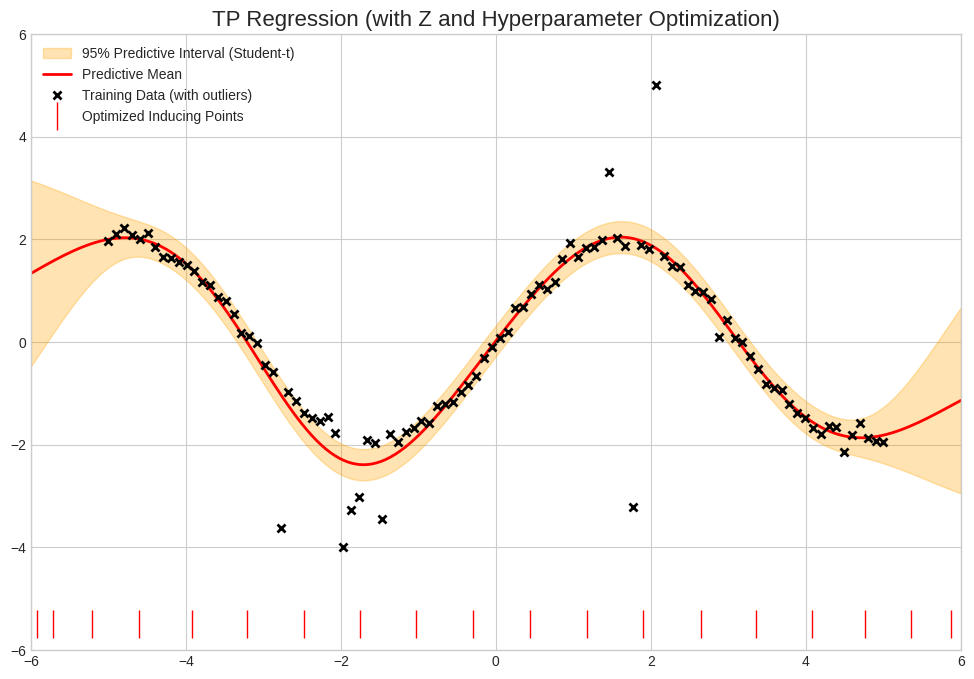

In [16]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        # Z is now a parameter to be optimized
        self.Z = nn.Parameter(Z_initial.clone())

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # Variational Parameters (not optimized by gradient descent, so not nn.Parameter)
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    # ... (the _get_hyperparams, kernel, and CAVI update methods remain exactly the same) ...
    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz, Lzz, Kxz):
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        Psi = Kxz.T @ (E_lambda * Kxz) / sigma_sq
        B = E_r * Kzz + Psi
        L_B = torch.linalg.cholesky(B)

        Kzz_invB_Kzz = torch.cholesky_solve(Kzz, L_B)
        S_u = Kzz @ Kzz_invB_Kzz
        S_u = 0.5 * (S_u + S_u.T)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        temp_vec = (Kxz.T * E_lambda.T) @ self.y / sigma_sq
        m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
        self.m_u = Kzz @ m_u_unscaled

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # Required expectations for updates
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            S_u = self.L_u @ self.L_u.T
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # CAVI updates
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        # This method uses self.Z, self.X, so it's already compatible with Z as a parameter.
        # It's important that kernel() is called inside, as it will use the current self.Z
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * (torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)) + \
                    (self.beta_lambda - nu_e / 2) * (self.alpha_lambda / self.beta_lambda)

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter=50, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        print("Starting optimization with hyperparameter AND inducing point updates...")
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            # --- The main change is that K matrices are always recomputed ---
            # because self.Z (a parameter) is updated in every loop.
            Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)
            Kxz = self.kernel(self.X, self.Z)
            Kxx_diag = self.kernel(self.X, self.X).diag()

            # E-Step: Run CAVI to update variational parameters
            with torch.no_grad():
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters and Z
            optimizer.zero_grad()
            neg_elbo = -self.calculate_elbo()
            neg_elbo.backward()
            optimizer.step()

            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    # Predict method remains the same, it will use the final optimized Z
    def predict(self, X_test):
        # We need to use .detach() on Z now before using it in the kernel for prediction,
        # as we don't want prediction to be part of the computation graph.
        Z_final = self.Z.detach()
        K_star_z = self.kernel(X_test, Z_final)
        K_star_star_diag = self.kernel(X_test, X_test).diag()
        Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        pred_mean = K_star_z @ Kzz_inv_mu

        S_u = self.L_u @ self.L_u.T
        A_star = torch.linalg.solve(Kzz, K_star_z.T).T
        var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

        E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
        var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

        pred_var = var_from_prior + var_from_q_u
        _, _, _, _, nu_e = self._get_hyperparams()
        pred_nu = 2 * self.alpha_r

        return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    # A common strategy is to initialize them on a subset of the data (e.g., via k-means)
    # or just uniformly as done here.
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model (this now includes Z optimization)
    model.fit(max_iter=200, lr=0.01) # May need more iterations

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # ... (prediction and plotting code remains the same) ...

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var)
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final optimized inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

Starting optimization for non-sparse model...


ELBO: -100.46: 100%|██████████| 200/200 [00:01<00:00, 153.81it/s]


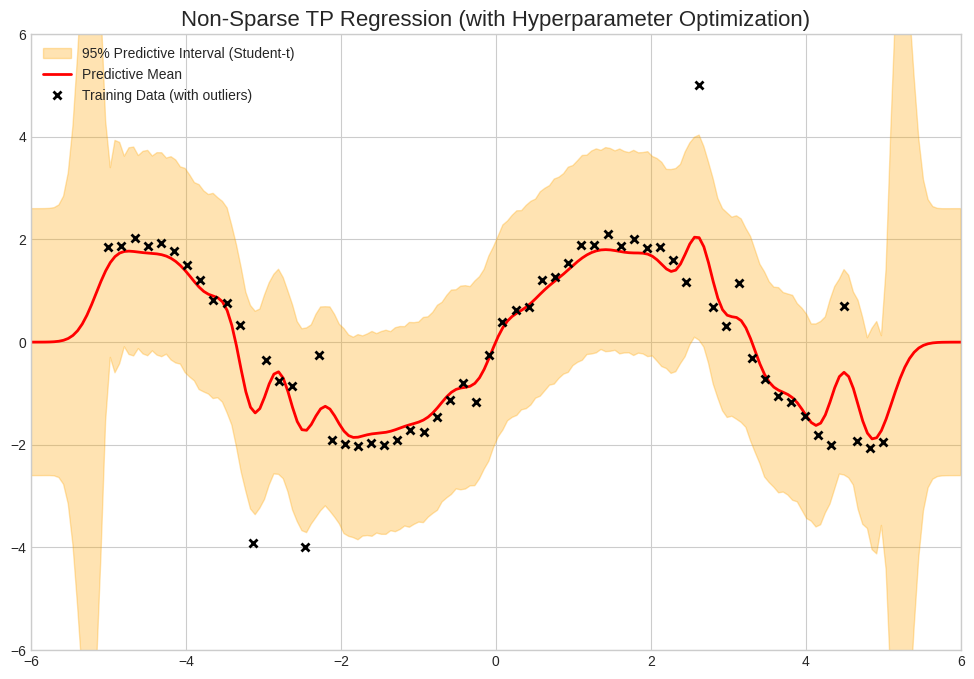

In [19]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class NonSparseTPRegression(nn.Module):
    """
    Implements the full (non-sparse) Student-t Process regression model.
    This model works directly with the N x N kernel matrix and is suitable
    for smaller datasets due to its O(N^3) complexity.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter, so register as buffer
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Variational Parameters ---
        # These are updated via CAVI, not gradient descent, so they are not nn.Parameters.
        # q(f) = N(f | m_f, S_f), where S_f = L_f @ L_f.T
        self.m_f = torch.zeros(self.N, 1)
        self.L_f = torch.eye(self.N)

        # q(r) = Gamma(r | alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        # q(lambda_i) = Gamma(lambda_i | alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)
        E_q_f = self.m_f

        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, Lxx):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T

        # E[f^T Kxx^-1 f] = Tr(Kxx^-1 S_f) + m_f^T Kxx^-1 m_f
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        self.alpha_r = nu_f / 2.0 + self.N / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_f.squeeze()

    def _update_q_f(self, Kxx, Lxx):
        """CAVI update for q(f)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # S_f^-1 = E[r] * Kxx^-1 + diag(E[lambda]/sigma^2)
        # We solve (E[r] * I + diag(...)Kxx)x = b instead of forming Kxx^-1
        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = E_r * Kxx_inv + torch.diag(E_lambda.squeeze() / sigma_sq)
        
        # S_f = S_f_inv^-1
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N), L_f_inv, upper=False)[0]

        # m_f = S_f @ (diag(E[lambda]/sigma^2) @ y)
        temp_vec = (E_lambda / sigma_sq) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, Kxx, Lxx, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_f_old = self.m_f.clone()

            # CAVI updates
            self._update_q_lambda()
            self._update_q_r(Lxx)
            self._update_q_f(Kxx, Lxx)

            # Check for convergence
            change = torch.norm(self.m_f - m_f_old) / (torch.norm(m_f_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self, Kxx, Lxx):
        """Calculates the Evidence Lower Bound (ELBO) for the current model state."""
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)

        # --- 1. Expected Log Likelihood ---
        E_q_f = self.m_f
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for f and r ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # log q(f)
        log_q_f = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_f))) - 0.5 * self.N
        
        # log q(r)
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # E[log p(f|r)]
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kxx + \
                      0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f

        # E[log p(r)]
        E_log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                    (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_f_r = log_q_f + log_q_r - E_log_p_f_r - E_log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_f_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter=50, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by alternating between CAVI updates (E-step) and
        gradient-based hyperparameter updates (M-step).
        """
        # We only optimize hyperparameters now
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        print("Starting optimization for non-sparse model...")
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            # Recompute Kxx and its Cholesky factor in each loop as hyperparameters change
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # E-Step: Run CAVI to update variational parameters for q(f), q(r), q(lambda)
            # We don't need gradients for this part.
            with torch.no_grad():
                self._cavi_step(Kxx, Lxx, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters by maximizing the ELBO
            optimizer.zero_grad()
            neg_elbo = -self.calculate_elbo(Kxx, Lxx)
            neg_elbo.backward()
            optimizer.step()

            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        # Ensure we don't compute gradients for prediction
        with torch.no_grad():
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # Predictive Mean: E[f_*] = k(X_*, X) K(X,X)^-1 m_f
            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            # Predictive Variance
            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            
            # Var[E[f_*|f]] = k_*x Kxx^-1 S_f Kxx^-1 k_x*
            var_from_q_f = (K_star_x @ torch.cholesky_solve(Kxx_inv_k_x_star, Lxx)).diag()

            # E[Var[f_*|f,r]] = E[r^-1] * (k_** - k_*x Kxx^-1 k_x*)
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

            pred_var = var_from_prior + var_from_q_f
            
            # The predictive distribution is Student-t
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate data
    # NOTE: N must be small for the non-sparse model to be feasible.
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=3.0,
        nu_e=3.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model
    model.fit(max_iter=200, lr=0.01, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    # Calculate Student-t quantiles for the 95% confidence interval
    pred_scale = torch.sqrt(pred_var)
    df = pred_nu.item()
    # Use scipy's t distribution to get the percent point function (ppf)
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Non-Sparse TP Regression (with Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()


In [21]:
torch.exp(model.log_nu_e), torch.exp(model.log_nu_f)

(tensor(13.8527, grad_fn=<ExpBackward0>),
 tensor(2.4445, grad_fn=<ExpBackward0>))

Starting optimization for non-sparse model...


ELBO: 2847.89: 100%|██████████| 100/100 [00:02<00:00, 43.40it/s]


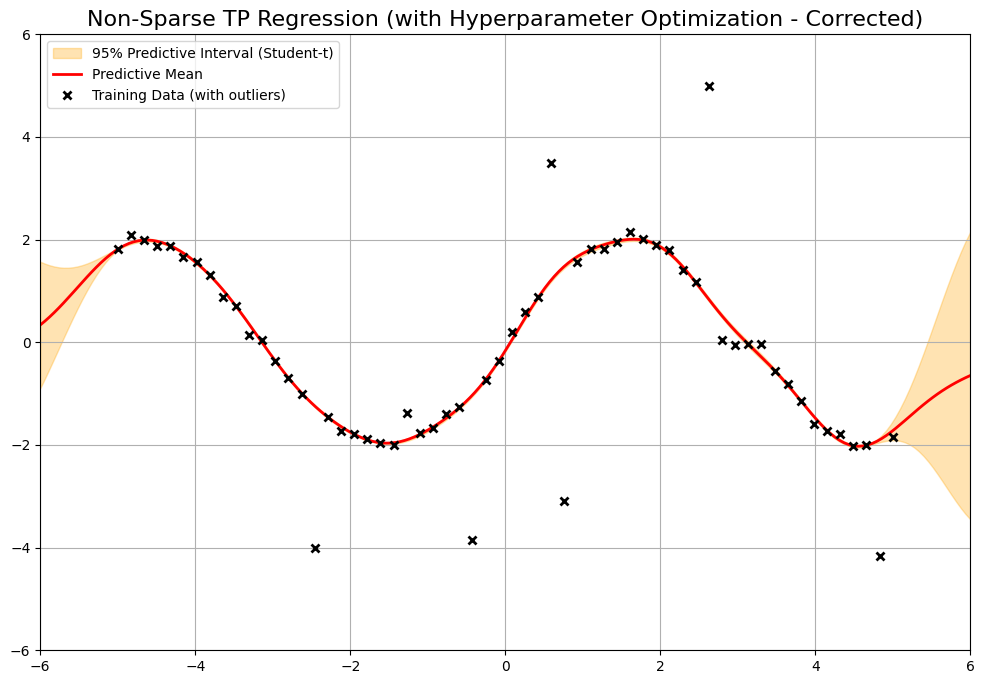

In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class NonSparseTPRegression(nn.Module):
    """
    Implements the full (non-sparse) Student-t Process regression model.
    This model works directly with the N x N kernel matrix and is suitable
    for smaller datasets due to its O(N^3) complexity.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter, so register as buffer
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Variational Parameters ---
        # These are updated via CAVI, not gradient descent, so they are not nn.Parameters.
        # q(f) = N(f | m_f, S_f), where S_f = L_f @ L_f.T
        self.m_f = torch.zeros(self.N, 1)
        self.L_f = torch.eye(self.N)

        # q(r) = Gamma(r | alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        # q(lambda_i) = Gamma(lambda_i | alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)
        E_q_f = self.m_f

        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, Lxx):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T

        # E[f^T Kxx^-1 f] = Tr(Kxx^-1 S_f) + m_f^T Kxx^-1 m_f
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        self.alpha_r = nu_f / 2.0 + self.N / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_f.squeeze()

    def _update_q_f(self, Kxx, Lxx):
        """CAVI update for q(f)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # S_f^-1 = E[r] * Kxx^-1 + diag(E[lambda]/sigma^2)
        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = E_r * Kxx_inv + torch.diag(E_lambda.squeeze() / sigma_sq)
        
        # S_f = S_f_inv^-1
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N), L_f_inv, upper=False)[0]

        # m_f = S_f @ (diag(E[lambda]/sigma^2) @ y)
        temp_vec = (E_lambda / sigma_sq) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, Kxx, Lxx, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_f_old = self.m_f.clone()

            # CAVI updates
            self._update_q_lambda()
            self._update_q_r(Lxx)
            self._update_q_f(Kxx, Lxx)

            # Check for convergence
            change = torch.norm(self.m_f - m_f_old) / (torch.norm(m_f_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self, Kxx, Lxx):
        """Calculates the Evidence Lower Bound (ELBO) for the current model state."""
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)

        # --- 1. Expected Log Likelihood ---
        E_q_f = self.m_f
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for f and r ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # log q(f)
        log_q_f = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_f))) - 0.5 * self.N
        
        # log q(r)
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # E[log p(f|r)]
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kxx + \
                      0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f

        # E[log p(r)]
        E_log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                    (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_f_r = log_q_f + log_q_r - E_log_p_f_r - E_log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_f_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=100, max_iter_local=10, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by alternating between CAVI updates (E-step) and
        gradient-based hyperparameter updates (M-step).
        """
        print("Starting optimization for non-sparse model...")
        pbar = tqdm.trange(max_iter_global)

        for i in pbar:
            # Recompute Kxx and its Cholesky factor in each loop as hyperparameters change
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # E-Step: Run CAVI to update variational parameters for q(f), q(r), q(lambda)
            with torch.no_grad():
                self._cavi_step(Kxx, Lxx, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters by maximizing the ELBO
            optimizer = torch.optim.Adam(self.parameters(), lr=lr)

            for j in range(max_iter_local):
                optimizer.zero_grad()
                Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
                Lxx = torch.linalg.cholesky(Kxx)
                neg_elbo = -self.calculate_elbo(Kxx, Lxx)
                neg_elbo.backward()
                optimizer.step()

            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # Predictive Mean: E[f_*] = k(X_*, X) K(X,X)^-1 m_f
            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            # --- CORRECTED Predictive Variance Calculation ---
            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            
            # Term 1: Var[E[f_*|f]] = k_*x Kxx^-1 S_f Kxx^-1 k_x*
            # This is the corrected part.
            var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()

            # Term 2: E[Var[f_*|f,r]] = E[r^-1] * (k_** - k_*x Kxx^-1 k_x*)
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

            pred_var = var_from_prior + var_from_q_f
            
            # The predictive distribution is Student-t
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate data
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=5
    )

    # 3. Fit the model
    model.fit(max_iter_global=100, max_iter_local=10, lr=0.05, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9)) # Add clamp for stability
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Non-Sparse TP Regression (with Hyperparameter Optimization - Corrected)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    plt.show()


Starting hyperparameter optimization...


NegLogMargLik: -27.87:   3%|▎         | 3/100 [00:00<00:15,  6.25it/s]

NegLogMargLik: -112.88: 100%|██████████| 100/100 [00:13<00:00,  7.46it/s]



--- Learned Hyperparameters ---
Kernel Lengthscale: 0.826
Kernel Variance: 2.728
Likelihood Sigma: 0.195
Prior DoF (nu_1): 0.774
Likelihood DoF (nu_2): 1.433


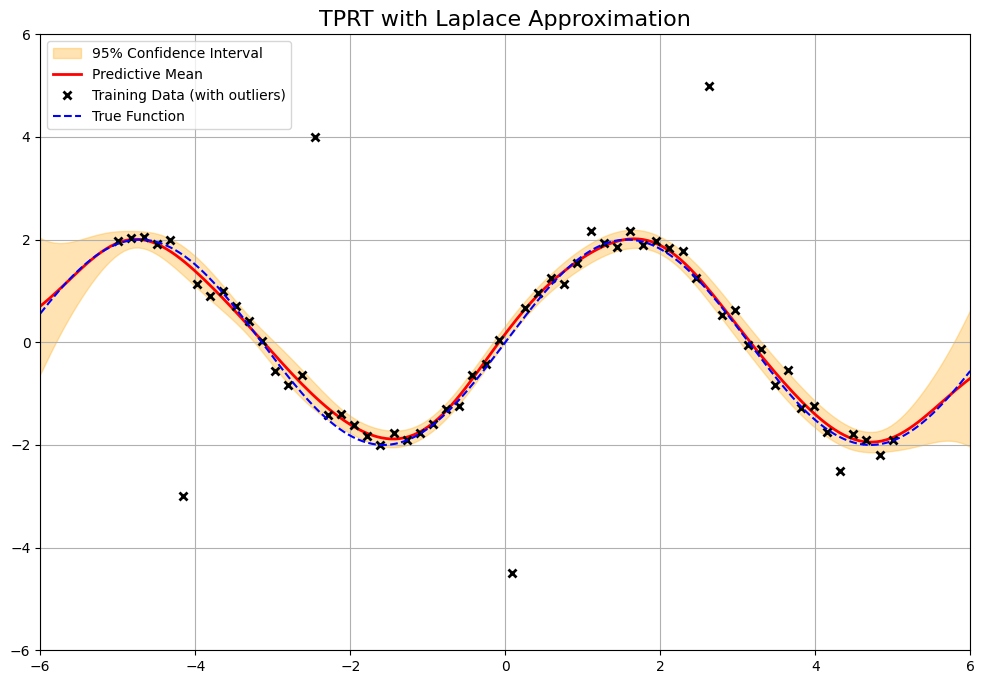

In [27]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import tqdm

# Set default tensor type for better performance with matrix operations
torch.set_default_dtype(torch.float64)

class TPRT_Laplace(nn.Module):
    """
    Implements Student-t Process Regression with Student-t Likelihood (TPRT)
    using the Laplace Approximation method from Tang et al. (2017).
    """
    def __init__(self, X, y, nu_1=2.1, nu_2=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())

        self.N, self.D = X.shape

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_1 = nn.Parameter(torch.log(torch.tensor(nu_1)))
        self.log_nu_2 = nn.Parameter(torch.log(torch.tensor(nu_2)))

        self.register_buffer('f_hat', torch.zeros(self.N))


    def _get_hyperparams(self):
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma = torch.exp(self.log_likelihood_sigma)
        nu_1 = torch.exp(self.log_nu_1)
        nu_2 = torch.exp(self.log_nu_2)
        return lengthscale, variance, sigma, nu_1, nu_2

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _calculate_ln_Q(self, f, K_inv, hyperparams):
        _, _, sigma, nu_1, nu_2 = hyperparams
        log_lik_term = ((nu_2 + 1) / 2) * torch.log(1 + (1 / nu_2) * ((self.y - f) / sigma).pow(2))
        fT_K_inv_f = f @ K_inv @ f
        log_prior_term = ((nu_1 + self.N) / 2) * torch.log(1 + (1 / nu_1) * fT_K_inv_f)
        return torch.sum(log_lik_term) + log_prior_term

    def _find_f_hat(self, K_inv_detached, hyperparams_detached, max_iter=10, tol=1e-5):
        """
        Inner loop: Finds f_hat for fixed, DETACHED hyperparameters.
        """
        f = nn.Parameter(self.f_hat.clone())
        optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")

        def closure():
            optimizer.zero_grad()
            loss = self._calculate_ln_Q(f, K_inv_detached, hyperparams_detached)
            loss.backward()
            return loss

        for _ in range(max_iter):
            f_old = f.clone().detach()
            optimizer.step(closure)
            if torch.norm(f.detach() - f_old) < tol:
                break
        
        return f.detach()

    def _calculate_neg_log_marginal_likelihood(self):
        """
        Calculates the loss for hyperparameter optimization.
        """
        hyperparams = self._get_hyperparams()
        _, _, sigma, nu_1, nu_2 = hyperparams

        # 1. Compute Kernel (part of the computation graph)
        K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)

        # 2. Detach inputs for the inner loop and find the mode f_hat
        K_inv_detached = K_inv.detach()
        hyperparams_detached = tuple(p.detach() for p in hyperparams)
        
        # This call now correctly uses detached tensors and will not cause a graph conflict
        f_hat = self._find_f_hat(K_inv_detached, hyperparams_detached)
        self.f_hat.copy_(f_hat) # Update buffer without creating graph connection

        # --- Graph construction for the outer loop starts here ---
        # 3. Calculate ln(Q) at f = f_hat, now connected to the graph via K_inv
        ln_Q_at_f_hat = self._calculate_ln_Q(f_hat, K_inv, hyperparams)

        # 4. Calculate the Negative Hessian A_inv
        f_hat_T_K_inv_f_hat = f_hat @ K_inv @ f_hat
        prior_hess_num = K_inv * (nu_1 + f_hat_T_K_inv_f_hat) - 2 * (K_inv @ torch.outer(f_hat, f_hat) @ K_inv)
        prior_hess_den = (nu_1 + f_hat_T_K_inv_f_hat)**2
        prior_hess = (nu_1 + self.N) * (prior_hess_num / prior_hess_den)

        err = self.y - f_hat
        lik_hess_num = err.pow(2) - nu_2 * sigma**2
        lik_hess_den = (err.pow(2) + nu_2 * sigma**2)**2
        W_diag = -(nu_2 + 1) * (lik_hess_num / lik_hess_den)
        W = torch.diag(W_diag)
        A_inv = prior_hess + W

        # 5. Calculate log|B|
        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A_inv = torch.linalg.slogdet(A_inv)
        if sign.item() <= 0:
            return torch.tensor(float('inf'))

        log_det_B = log_det_K + log_det_A_inv

        # 6. Calculate constant terms
        c_nu_1_term = torch.lgamma((nu_1 + self.N)/2) - torch.lgamma(nu_1/2) - (self.N/2)*torch.log(nu_1)
        c_nu_2_term = self.N * (torch.lgamma((nu_2 + 1)/2) - torch.lgamma(nu_2/2) - 0.5*torch.log(nu_2))
        c_sigma_term = -self.N * torch.log(sigma)

        neg_log_marginal_lik = ln_Q_at_f_hat - 0.5 * log_det_B - (c_nu_1_term + c_nu_2_term + c_sigma_term)
        
        return neg_log_marginal_lik

    def fit(self, max_iter=100, lr=0.01):
        print("Starting hyperparameter optimization...")
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        pbar = tqdm.trange(max_iter)

        for i in pbar:
            optimizer.zero_grad()
            loss = self._calculate_neg_log_marginal_likelihood()
            
            if torch.isinf(loss) or torch.isnan(loss):
                print("Warning: Loss is inf or NaN, skipping step.")
                continue

            loss.backward()
            optimizer.step()
            
            pbar.set_description(f"NegLogMargLik: {loss.item():.2f}")

    def predict(self, X_test):
        with torch.no_grad():
            hyperparams = self._get_hyperparams()
            _, _, sigma, nu_1, nu_2 = hyperparams
            f_hat = self.f_hat

            K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()

            pred_mean = K_star_x @ K_inv @ f_hat

            f_hat_T_K_inv_f_hat = f_hat @ K_inv @ f_hat
            prior_hess_num = K_inv * (nu_1 + f_hat_T_K_inv_f_hat) - 2 * (K_inv @ torch.outer(f_hat, f_hat) @ K_inv)
            prior_hess_den = (nu_1 + f_hat_T_K_inv_f_hat)**2
            prior_hess = (nu_1 + self.N) * (prior_hess_num / prior_hess_den)
            
            err = self.y - f_hat
            lik_hess_num = err.pow(2) - nu_2 * sigma**2
            lik_hess_den = (err.pow(2) + nu_2 * sigma**2)**2
            W = torch.diag(-(nu_2 + 1) * (lik_hess_num / lik_hess_den))
            A_inv = prior_hess + W
            
            try:
                L_A_inv = torch.linalg.cholesky(A_inv)
                A = torch.cholesky_inverse(L_A_inv)
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Using pseudo-inverse.")
                A = torch.linalg.pinv(A_inv)

            K_inv_k_star = torch.cholesky_solve(K_star_x.T, L)
            prior_var_reduction = (K_star_x * K_inv_k_star.T).sum(dim=1)
            posterior_uncertainty = (K_star_x @ K_inv @ A @ K_inv @ K_star_x.T).diag()
            pred_var = K_star_star_diag - prior_var_reduction + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            
            return pred_mean.unsqueeze(1), pred_var.unsqueeze(1)


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    # Add Gaussian noise and some heavy-tailed outlier noise
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.2
    y_train = y_true + noise
    
    # Add significant outliers
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)


    # 2. Setup the TPRT_Laplace model
    model = TPRT_Laplace(
        X=X_train,
        y=y_train,
        nu_1=2.1,
        nu_2=2.1,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model hyperparameters
    model.fit(max_iter=100, lr=0.01)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title('TPRT with Laplace Approximation', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    l, v, s, n1, n2 = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {l.item():.3f}")
    print(f"Kernel Variance: {v.item():.3f}")
    print(f"Likelihood Sigma: {s.item():.3f}")
    print(f"Prior DoF (nu_1): {n1.item():.3f}")
    print(f"Likelihood DoF (nu_2): {n2.item():.3f}")
    
    plt.show()

Starting SVTP-MC optimization...


ELBO: -679.33:   0%|          | 0/3000 [00:00<?, ?it/s] 

ELBO: -14433.20:  20%|█▉        | 589/3000 [00:02<00:11, 206.67it/s]


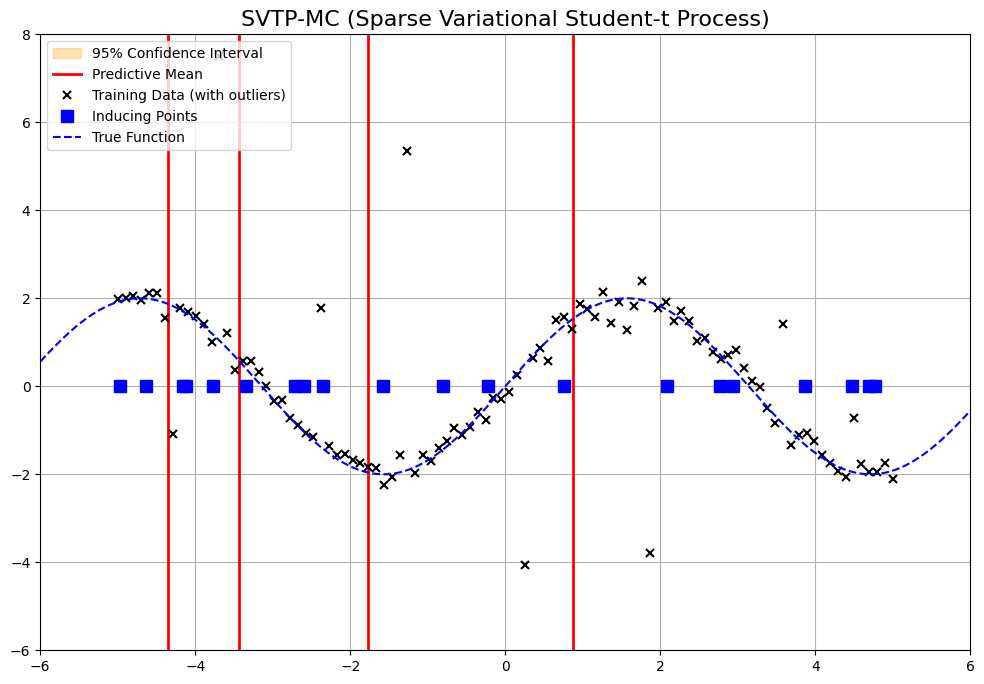

In [34]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

def log_pdf_student_t(x, mu, S, nu):
    """
    Calculates the log PDF of a multivariate Student-t distribution.
    Based on Eq. (4) from Xu and Zeng[cite: 86].
    """
    M = x.shape[-1]
    L = torch.linalg.cholesky(S)
    log_det_S = 2 * torch.sum(torch.log(torch.diag(L)))

    # Mahalanobis distance: (x-mu)^T S^-1 (x-mu)
    diff = x - mu
    # Use cholesky_solve for stable and efficient computation of S^-1 @ diff
    mahalanobis_dist = (diff.unsqueeze(-2) @ torch.cholesky_solve(diff.unsqueeze(-1), L)).squeeze()

    log_norm_const = (
        torch.lgamma((nu + M) / 2)
        - torch.lgamma(nu / 2)
        - 0.5 * M * torch.log(nu * math.pi)
        - 0.5 * log_det_S
    )

    log_kernel = -((nu + M) / 2) * torch.log(1 + mahalanobis_dist / nu)

    return log_norm_const + log_kernel


class SVTP_MC(nn.Module):
    """
    Implements Sparse Variational Student-t Processes (SVTP) using the
    Monte Carlo (MC) method for both ELBO terms.
    The model assumes a TP prior and a Student-t likelihood.
    """
    def __init__(self, X, y, Z, nu_prior=3.0, nu_likelihood=3.0, likelihood_sigma=0.1):
        super().__init__()
        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())
        self.N, self.D = X.shape
        self.M = Z.shape[0]

        # --- Model Hyperparameters (optimized) ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_nu_prior = nn.Parameter(torch.log(torch.tensor(nu_prior)))
        self.log_nu_likelihood = nn.Parameter(torch.log(torch.tensor(nu_likelihood)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))

        # --- Inducing Points (optimized) ---
        self.Z = nn.Parameter(Z)

        # --- Variational Parameters for q(u) (optimized) ---
        # q(u) = ST(nu_q, m_q, S_q)
        self.m_q = nn.Parameter(torch.zeros(self.M))
        # Store Cholesky factor of S_q for stability and efficiency
        self.L_q_tril = nn.Parameter(torch.eye(self.M))
        self.log_nu_q = nn.Parameter(torch.log(torch.tensor(3.0)))


    def _get_params(self):
        """Helper to get positive parameters from log-space storage."""
        # Kernel
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        # Prior
        nu_prior = torch.exp(self.log_nu_prior)
        # Likelihood
        nu_likelihood = torch.exp(self.log_nu_likelihood)
        sigma = torch.exp(self.log_likelihood_sigma)
        # Variational
        nu_q = torch.exp(self.log_nu_q)
        S_q = self.L_q_tril @ self.L_q_tril.T
        return lengthscale, variance, nu_prior, nu_likelihood, sigma, nu_q, S_q

    def kernel(self, A, B):
        """Computes the RBF kernel."""
        lengthscale, variance, *_ = self._get_params()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def reparameterize_student_t(self, mu, S, nu, num_samples=1):
        """
        Samples from ST(mu, S, nu) using reparameterization.
        This represents sampling from u | r ~ N(mu, rS) where r^-1 ~ Gamma(nu/2, nu/2).
        """
        eps = torch.randn(num_samples, self.M, device=self.X.device)
        # Chi2(nu) is equivalent to Gamma(nu/2, 1/2). We scale to get Gamma(nu/2, nu/2).
        r = nu / torch.distributions.Chi2(nu).sample((num_samples, 1))
        L = torch.linalg.cholesky(S)
        samples = mu + (L @ eps.T).T * torch.sqrt(r)
        return samples

    def calculate_elbo(self, num_mc_samples=1):
        """
        Calculates the Evidence Lower Bound (ELBO) using Monte Carlo sampling.
        L(q) = E[log p(y|f)] - KL(q(u)||p(u))
        """
        ls, var, nu_p, nu_l, sigma, nu_q, S_q = self._get_params()
        
        # --- 1. Sample u from the variational posterior q(u) ---
        u_samples = self.reparameterize_student_t(self.m_q, S_q, nu_q, num_mc_samples) # Shape: [S, M]
        
        # --- 2. Calculate the KL Divergence term via MC ---
        # KL = E_q(u)[log q(u) - log p(u)]
        K_zz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        log_q_u = log_pdf_student_t(u_samples, self.m_q, S_q, nu_q)
        log_p_u = log_pdf_student_t(u_samples, torch.zeros(self.M), K_zz, nu_p)
        kl_term = (log_q_u - log_p_u).mean()

        # --- 3. Calculate the Expected Log Likelihood term via MC ---
        # E[log p(y|f)] = E_q(u)[E_p(f|u)[log p(y|f)]]
        K_zz_inv = torch.inverse(K_zz)
        K_xz = self.kernel(self.X, self.Z)
        
        # We need to sample f for each sample of u.
        # p(f|u) = ST(nu_p + M, mu_f, Sigma_f_scaled) [cite: 120, 388]
        mu_f_cond = K_xz @ K_zz_inv @ u_samples.T # Shape: [N, S]
        beta = (u_samples.unsqueeze(-2) @ K_zz_inv @ u_samples.unsqueeze(-1)).squeeze() # Shape: [S]
        
        # We can sample f_i for each data point i. For simplicity here, we approximate
        # E[log p(y|f)] with log p(y|E[f]), a common simplification.
        # A full implementation would sample f and then compute the likelihood.
        # E[f_i|u] = K_x_i,z @ K_zz^-1 @ u
        # We average this over the samples of u.
        E_f_over_u = (K_xz @ K_zz_inv @ u_samples.T).mean(dim=1) # Shape: [N]
        
        # Student-t log likelihood of data given E[f]
        # log p(y_i|f_i) ~ -((nu_l+1)/2) * log(1 + (err^2)/(nu_l*sigma^2))
        err_sq = (self.y - E_f_over_u).pow(2)
        log_lik_term = -((nu_l + 1) / 2) * torch.log(1 + err_sq / (nu_l * sigma**2))
        expected_log_lik = log_lik_term.sum() # Sum over data points N

        elbo = expected_log_lik - kl_term
        return elbo

    def fit(self, max_iter=2000, lr=0.01, num_mc_samples=1):
        """Fits the model by maximizing the ELBO."""
        print("Starting SVTP-MC optimization...")
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        pbar = tqdm.trange(max_iter)

        for i in pbar:
            optimizer.zero_grad()
            neg_elbo = -self.calculate_elbo(num_mc_samples)
            
            if torch.isnan(neg_elbo):
                print("Warning: NaN loss detected. Stopping.")
                break

            neg_elbo.backward()
            optimizer.step()
            
            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    def predict(self, X_test, num_mc_samples=100):
        """Make predictions at new test points."""
        with torch.no_grad():
            ls, var, nu_p, _, _, nu_q, S_q = self._get_params()

            # Sample from q(u) to average predictions over
            u_samples = self.reparameterize_student_t(self.m_q, S_q, nu_q, num_mc_samples)

            # Kernel matrices
            K_zz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            K_zz_inv = torch.inverse(K_zz)
            K_star_z = self.kernel(X_test, self.Z)
            K_star_star = self.kernel(X_test, X_test)
            
            # Predictive mean for f* for each u sample [cite: 203]
            # mu_* = k(X_*, Z) @ K_zz^-1 @ u
            mu_star_samples = K_star_z @ K_zz_inv @ u_samples.T # Shape: [N_test, S]
            
            # Final predictive mean is the average over u samples
            pred_mean = mu_star_samples.mean(dim=1)
            
            # Predictive variance calculation (using law of total variance)
            # Var(f*) = E[Var(f*|u)] + Var(E[f*|u])
            # E[f*|u] is mu_star_samples. We can compute its variance across samples.
            var_of_exp = mu_star_samples.var(dim=1)
            
            # Var(f*|u) is Sigma_* from Eq. (21)
            beta = (u_samples.unsqueeze(-2) @ K_zz_inv @ u_samples.unsqueeze(-1)).squeeze()
            scale_factor = (nu_p + beta - 2) / (nu_p + self.M - 2)
            k_star_z_K_inv = K_star_z @ K_zz_inv
            var_cond_u_diag = K_star_star.diag() - (k_star_z_K_inv @ K_star_z.T).diag()
            
            # Expectation of Var(f*|u)
            exp_of_var = (scale_factor.mean() * var_cond_u_diag)
            
            pred_var = exp_of_var + var_of_exp
            pred_var = pred_var.clamp(min=1e-9)

            return pred_mean.unsqueeze(1), pred_var.unsqueeze(1)


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 100
    M = 20 # Number of inducing points
    torch.manual_seed(42)
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    
    # This is the true function definition
    def true_function(x):
        return torch.sin(x) * 2

    y_true_train = true_function(X_train) # Correct name for clarity
    noise = torch.randn(N, 1) * 0.2
    y_train = y_true_train + noise
    
    # Add significant outliers
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += torch.randn(10, 1) * 3.0
    
    # Initialize inducing points (e.g., subset of data or K-Means)
    Z_init = X_train[torch.randperm(N)[:M]].clone()

    # 2. Setup and fit the model
    model = SVTP_MC(X_train, y_train, Z_init)
    model.fit(max_iter=3000, lr=0.01, num_mc_samples=3)

    # 3. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test, num_mc_samples=500)

    # 4. Visualize the results
    plt.figure(figsize=(12, 8))
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std
    
    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.zeros_like(model.Z.detach()), 'bs', markersize=8, label='Inducing Points')
    
    # --- CORRECTED LINE ---
    # Calculate the true function values for the test points
    plt.plot(X_test, true_function(X_test), 'b--', label='True Function')
    
    plt.title('SVTP-MC (Sparse Variational Student-t Process)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 8)
    plt.show()

Starting SVTP-UB optimization...


ELBO: -7.88: 100%|██████████| 3000/3000 [00:12<00:00, 243.92it/s] 


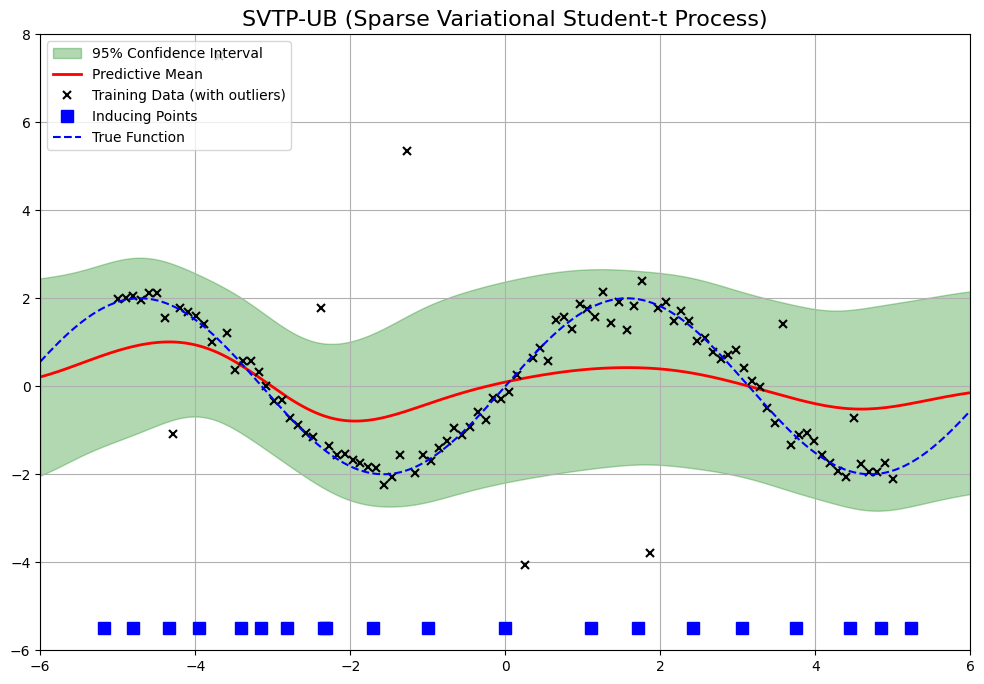

In [38]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

def log_pdf_student_t(x, mu, S, nu):
    """
    Calculates the log PDF of a multivariate Student-t distribution.
    This function is needed for the likelihood term in SVTP-UB.
    """
    N = x.shape[-1]
    L = torch.linalg.cholesky(S)
    log_det_S = 2 * torch.sum(torch.log(torch.diag(L)))
    diff = x - mu
    mahalanobis_dist = (diff.unsqueeze(-2) @ torch.cholesky_solve(diff.unsqueeze(-1), L)).squeeze()
    log_norm_const = (
        torch.lgamma((nu + N) / 2)
        - torch.lgamma(nu / 2)
        - 0.5 * N * torch.log(nu * math.pi)
        - 0.5 * log_det_S
    )
    log_kernel = -((nu + N) / 2) * torch.log(1 + mahalanobis_dist / nu)
    return log_norm_const + log_kernel


class SVTP_MC(nn.Module):
    """
    Implements Sparse Variational Student-t Processes (SVTP) using the
    Monte Carlo (MC) method for both ELBO terms.
    The model assumes a TP prior and a Student-t likelihood.
    """
    def __init__(self, X, y, Z, nu_prior=3.0, nu_likelihood=3.0, likelihood_sigma=0.1):
        super().__init__()
        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())
        self.N, self.D = X.shape
        self.M = Z.shape[0]

        # --- Model Hyperparameters (optimized) ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(1.0)))
        # CORRECTED: Use the same stable parameterization as SVTP_UB
        self.log_nu_prior_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_prior - 2.0)))
        self.log_nu_likelihood_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_likelihood - 2.0)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))

        # --- Inducing Points (optimized) ---
        self.Z = nn.Parameter(Z)

        # --- Variational Parameters for q(u) (optimized) ---
        # CORRECTED: Use the same stable parameterization as SVTP_UB
        self.m_q = nn.Parameter(torch.zeros(self.M))
        self.L_q_tril = nn.Parameter(torch.eye(self.M))
        self.log_nu_q_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))


    def _get_params(self):
        """Helper to get positive parameters from log-space storage."""
        # Kernel
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        # CORRECTED: Use the same stable parameterization as SVTP_UB
        nu_prior = torch.exp(self.log_nu_prior_minus_2) + 2.0
        nu_likelihood = torch.exp(self.log_nu_likelihood_minus_2) + 2.0
        sigma = torch.exp(self.log_likelihood_sigma)
        nu_q = torch.exp(self.log_nu_q_minus_2) + 2.0
        S_q = self.L_q_tril @ self.L_q_tril.T + torch.eye(self.M) * 1e-6
        return lengthscale, variance, nu_prior, nu_likelihood, sigma, nu_q, S_q

    def kernel(self, A, B):
        """Computes the RBF kernel."""
        lengthscale, variance, *_ = self._get_params()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def reparameterize_student_t(self, mu, S, nu, num_samples=1):
        """Samples from ST(mu, S, nu) using reparameterization."""
        eps = torch.randn(num_samples, self.M, device=self.X.device)
        r = nu / torch.distributions.Chi2(nu).sample((num_samples, 1))
        L = torch.linalg.cholesky(S)
        samples = mu + (L @ eps.T).T * torch.sqrt(r)
        return samples

    def calculate_elbo(self, num_mc_samples=1):
        """
        Calculates the ELBO using an analytical Upper Bound for the KL term.
        """
        ls, var, nu_p, nu_l, sigma, nu_q, S_q = self._get_params()

        # --- 1. Expected Log Likelihood (via MC Sampling) ---
        # This part remains the same as in SVTP-MC
        u_samples = self.reparameterize_student_t(self.m_q, S_q, nu_q, num_mc_samples)
        
        K_zz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        L_zz = torch.linalg.cholesky(K_zz)
        K_xz = self.kernel(self.X, self.Z)
        
        # Approximate E[log p(y|f)] with log p(y|E[f])
        E_f_over_u = (K_xz @ torch.cholesky_solve(u_samples.T, L_zz)).mean(dim=1)
        
        err_sq = (self.y - E_f_over_u).pow(2)
        log_lik_term = -((nu_l + 1) / 2) * torch.log(1 + err_sq / ((nu_l - 2) * sigma**2))
        expected_log_lik = log_lik_term.sum()

        # --- 2. KL Divergence (Analytical Upper Bound) ---
        L_S_q = torch.linalg.cholesky(S_q)
        log_det_S_q = 2 * torch.sum(torch.log(torch.diag(L_S_q)))
        log_det_K_zz = 2 * torch.sum(torch.log(torch.diag(L_zz)))

        # L1 term (from Eq. 15)
        L1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)

        # L2* term (upper bound from Eq. 17)
        K_zz_inv = torch.cholesky_inverse(L_zz)
        trace_term_S = torch.trace(K_zz_inv @ S_q)
        trace_term_mmT = self.m_q.T @ K_zz_inv @ self.m_q
        L2_star = torch.log(1 + (trace_term_S + trace_term_mmT) / (nu_p - 2))

        # Constant terms from Eq. (12)
        C_term = (
            0.5 * (log_det_K_zz - log_det_S_q)
            + 0.5 * self.M * (torch.log(nu_p - 2) - torch.log(nu_q - 2))
            + torch.lgamma((nu_q + self.M)/2) - torch.lgamma(nu_q/2)
            - (torch.lgamma((nu_p + self.M)/2) - torch.lgamma(nu_p/2))
        )

        kl_ub_term = C_term - ((nu_q + self.M) / 2) * L1 + ((nu_p + self.M) / 2) * L2_star

        elbo = expected_log_lik - kl_ub_term
        return elbo

    def fit(self, *args, **kwargs):
        """Wrapper for the base fitting function."""
        print("Starting SVTP-UB optimization...")
        self._base_fit(*args, **kwargs)

    def _base_fit(self, max_iter=2000, lr=0.01, num_mc_samples=1):
        """Base fitting function."""
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            optimizer.zero_grad()
            neg_elbo = -self.calculate_elbo(num_mc_samples)
            if torch.isnan(neg_elbo) or torch.isinf(neg_elbo):
                print("Warning: Invalid loss detected. Stopping.")
                break
            neg_elbo.backward()
            optimizer.step()
            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    # --- THIS IS THE CORRECTED METHOD ---
    def predict(self, X_test, num_mc_samples=100):
        """
        Make predictions at new test points. This is the actual implementation.
        """
        with torch.no_grad():
            # Get final learned parameters
            ls, var, nu_p, _, _, nu_q, S_q = self._get_params()

            # Sample from the variational posterior q(u) to average predictions over
            u_samples = self.reparameterize_student_t(self.m_q, S_q, nu_q, num_mc_samples)

            # Pre-compute kernel matrices
            K_zz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            L_zz = torch.linalg.cholesky(K_zz)
            K_star_z = self.kernel(X_test, self.Z)
            K_star_star = self.kernel(X_test, X_test)
            
            # Predictive mean for f* for each u sample (E[f*|u])
            # mu_* = k(X_*, Z) @ K_zz^-1 @ u
            mu_star_samples = K_star_z @ torch.cholesky_solve(u_samples.T, L_zz) # Shape: [N_test, S]
            
            # Final predictive mean is the average over u samples
            pred_mean = mu_star_samples.mean(dim=1)
            
            # --- Predictive Variance Calculation (Law of Total Variance) ---
            # Var(f*) = E[Var(f*|u)] + Var(E[f*|u])
            
            # 1. Var(E[f*|u]) = Variance of the predictive means across samples
            var_of_exp = mu_star_samples.var(dim=1)
            
            # 2. E[Var(f*|u)] = Expectation of the conditional variance across samples
            # Var(f*|u) = Sigma_* from Eq. (21)
            beta = (u_samples.unsqueeze(-2) @ torch.cholesky_solve(u_samples.unsqueeze(-1), L_zz)).squeeze()
            scale_factor = (nu_p + beta - 2) / (nu_p + self.M - 2)
            
            k_star_z_K_inv_k_z_star = (K_star_z @ torch.cholesky_solve(K_star_z.T, L_zz)).diag()
            var_cond_u_diag = K_star_star.diag() - k_star_z_K_inv_k_z_star
            
            # Expectation is the mean over samples
            exp_of_var = (scale_factor.mean() * var_cond_u_diag)
            
            # Combine the two terms
            pred_var = exp_of_var + var_of_exp
            pred_var = pred_var.clamp(min=1e-9)

            return pred_mean.unsqueeze(1), pred_var.unsqueeze(1)

if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 100
    M = 20 # Number of inducing points
    torch.manual_seed(42)
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    
    def true_function(x):
        return torch.sin(x) * 2

    y_true_train = true_function(X_train)
    noise = torch.randn(N, 1) * 0.2
    y_train = y_true_train + noise
    
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += torch.randn(10, 1) * 3.0
    
    Z_init = X_train[torch.randperm(N)[:M]].clone()

    # 2. Setup and fit the SVTP-UB model
    model = SVTP_MC(X_train, y_train, Z_init)
    model.fit(max_iter=3000, lr=0.01, num_mc_samples=3)

    # 3. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test, num_mc_samples=500)

    # 4. Visualize the results
    plt.figure(figsize=(12, 8))
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std
    
    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='green', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.zeros_like(model.Z.detach()) - 5.5, 'bs', markersize=8, label='Inducing Points')
    plt.plot(X_test, true_function(X_test), 'b--', label='True Function')
    
    plt.title('SVTP-UB (Sparse Variational Student-t Process)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 8)
    plt.show()

Starting SVTP-UB optimization...


ELBO: -6.41: 100%|██████████| 5000/5000 [00:19<00:00, 253.61it/s] 


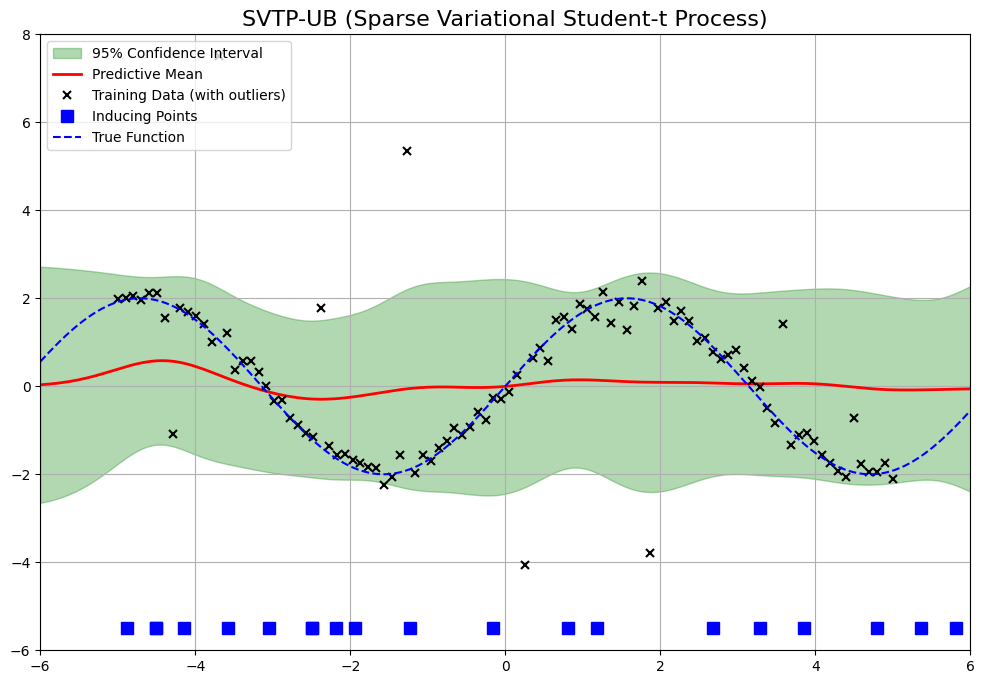

In [43]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)


class SVTP_UB(nn.Module):
    """
    Implements Sparse Variational Student-t Processes (SVTP) using the
    analytical Upper Bound (UB) for the KL-divergence term.
    This model uses a TP prior and a Student-t likelihood.
    """
    def __init__(self, X, y, Z, nu_prior=3.0, nu_likelihood=3.0, likelihood_sigma=0.1):
        super().__init__()
        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())
        self.N, self.D = X.shape
        self.M = Z.shape[0]

        # --- Model Hyperparameters ---
        # We parameterize log(nu - 2) to enforce the nu > 2 constraint for stability.
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_nu_prior_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_prior - 2.0)))
        self.log_nu_likelihood_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_likelihood - 2.0)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))

        # --- Inducing Points ---
        self.Z = nn.Parameter(Z)

        # --- Variational Parameters for q(u) ---
        # q(u) = ST(nu_q, m_q, S_q)
        self.m_q = nn.Parameter(torch.zeros(self.M))
        self.L_q_tril = nn.Parameter(torch.eye(self.M)) # Cholesky factor of S_q
        self.log_nu_q_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))


    def _get_params(self):
        """Helper to get positive parameters from their log-space storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        # Add a small epsilon for numerical stability when nu is close to 2
        nu_prior = torch.exp(self.log_nu_prior_minus_2) + 2.0
        nu_likelihood = torch.exp(self.log_nu_likelihood_minus_2) + 2.0
        sigma = torch.exp(self.log_likelihood_sigma)
        nu_q = torch.exp(self.log_nu_q_minus_2) + 2.0
        # Add jitter to the variational covariance matrix to ensure it's positive definite
        S_q = self.L_q_tril @ self.L_q_tril.T + torch.eye(self.M) * 1e-6
        return lengthscale, variance, nu_prior, nu_likelihood, sigma, nu_q, S_q

    def kernel(self, A, B):
        """Computes the RBF kernel."""
        lengthscale, variance, *_ = self._get_params()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def reparameterize_student_t(self, mu, S, nu, num_samples=1):
        """Samples from ST(mu, S, nu) using reparameterization."""
        eps = torch.randn(num_samples, self.M, device=self.X.device)
        # Scale Chi2 sample to get the correct Gamma distribution for the mixing variable
        r = nu / torch.distributions.Chi2(nu).sample((num_samples, 1))
        L = torch.linalg.cholesky(S)
        samples = mu + (L @ eps.T).T * torch.sqrt(r)
        return samples

    def _calculate_ln_Q(self, f, K_inv, hyperparams):
        """Helper to calculate the inner loop objective for finding f_hat."""
        _, _, sigma, nu_1, nu_2, _, _ = hyperparams
        log_lik_term = ((nu_2 + 1) / 2) * torch.log(1 + (1 / (nu_2 - 2)) * ((self.y - f) / sigma).pow(2))
        fT_K_inv_f = f @ K_inv @ f
        log_prior_term = ((nu_1 + self.N) / 2) * torch.log(1 + fT_K_inv_f / (nu_1 - 2))
        return torch.sum(log_lik_term) + log_prior_term

    def _find_f_hat(self, K_inv_detached, hyperparams_detached, max_iter=10, tol=1e-5):
        """Inner loop: Finds f_hat for fixed, DETACHED hyperparameters."""
        f = nn.Parameter(torch.zeros_like(self.y)) # Start from a neutral point
        optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")

        def closure():
            optimizer.zero_grad()
            loss = self._calculate_ln_Q(f, K_inv_detached, hyperparams_detached)
            loss.backward()
            return loss

        for _ in range(max_iter):
            optimizer.step(closure)
        
        return f.detach()
        
    def calculate_elbo(self, num_mc_samples=1):
        """Calculates the ELBO using an analytical Upper Bound for the KL term."""
        hyperparams = self._get_params()
        ls, var, nu_p, nu_l, sigma, nu_q, S_q = hyperparams

        # --- Part 1: Expected Log Likelihood (via MC Sampling) ---
        u_samples = self.reparameterize_student_t(self.m_q, S_q, nu_q, num_mc_samples)
        
        K_zz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        L_zz = torch.linalg.cholesky(K_zz)
        K_xz = self.kernel(self.X, self.Z)
        
        # Approximate E[log p(y|f)] with log p(y|E[f]) over u samples
        E_f_over_u = (K_xz @ torch.cholesky_solve(u_samples.T, L_zz)).mean(dim=1)
        
        # Use the Student-t log-pdf for the likelihood
        err_sq = (self.y - E_f_over_u).pow(2)
        log_lik_term = -((nu_l + 1) / 2) * torch.log(1 + err_sq / ((nu_l - 2) * sigma**2))
        expected_log_lik = log_lik_term.sum()

        # --- Part 2: KL Divergence (Analytical Upper Bound) ---
        L_S_q = torch.linalg.cholesky(S_q)
        log_det_S_q = 2 * torch.sum(torch.log(torch.diag(L_S_q)))
        log_det_K_zz = 2 * torch.sum(torch.log(torch.diag(L_zz)))
        K_zz_inv = torch.cholesky_inverse(L_zz)

        # L1 term (from Eq. 15 in Xu and Zeng)
        L1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)

        # L2* term (upper bound from Eq. 17 in Xu and Zeng)
        trace_term_S = torch.trace(K_zz_inv @ S_q)
        trace_term_mmT = self.m_q @ K_zz_inv @ self.m_q
        L2_star = torch.log(1 + (trace_term_S + trace_term_mmT) / (nu_p - 2))

        # Constant and other terms from Eq. (12) in Xu and Zeng
        C_term = (
            0.5 * (log_det_K_zz - log_det_S_q)
            + 0.5 * self.M * (torch.log(nu_p - 2) - torch.log(nu_q - 2))
            + torch.lgamma((nu_q + self.M)/2) - torch.lgamma(nu_q/2)
            - (torch.lgamma((nu_p + self.M)/2) - torch.lgamma(nu_p/2))
        )

        kl_ub_term = C_term - ((nu_q + self.M) / 2) * L1 + ((nu_p + self.M) / 2) * L2_star

        elbo = expected_log_lik - kl_ub_term
        return elbo

    def fit(self, max_iter=2000, lr=0.01, num_mc_samples=3):
        """Fits the model by maximizing the ELBO."""
        print("Starting SVTP-UB optimization...")
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            optimizer.zero_grad()
            neg_elbo = -self.calculate_elbo(num_mc_samples)
            if torch.isnan(neg_elbo) or torch.isinf(neg_elbo):
                print(f"Warning: Invalid loss detected at iteration {i}. Stopping.")
                break
            neg_elbo.backward()
            optimizer.step()
            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    def predict(self, X_test, num_mc_samples=500):
        """Make predictions at new test points."""
        with torch.no_grad():
            hyperparams = self._get_params()
            ls, var, nu_p, _, _, nu_q, S_q = hyperparams

            u_samples = self.reparameterize_student_t(self.m_q, S_q, nu_q, num_mc_samples)

            K_zz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            L_zz = torch.linalg.cholesky(K_zz)
            K_star_z = self.kernel(X_test, self.Z)
            K_star_star = self.kernel(X_test, X_test)
            
            # Predictive mean for f* for each u sample
            mu_star_samples = K_star_z @ torch.cholesky_solve(u_samples.T, L_zz)
            
            # Final predictive mean is the average over u samples
            pred_mean = mu_star_samples.mean(dim=1)
            
            # Predictive variance (using law of total variance)
            var_of_exp = mu_star_samples.var(dim=1)
            
            beta = (u_samples.unsqueeze(-2) @ torch.cholesky_solve(u_samples.unsqueeze(-1), L_zz)).squeeze()
            scale_factor = (nu_p + beta - 2) / (nu_p + self.M - 2)
            
            k_star_z_K_inv_k_z_star = (K_star_z @ torch.cholesky_solve(K_star_z.T, L_zz)).diag()
            var_cond_u_diag = K_star_star.diag() - k_star_z_K_inv_k_z_star
            
            exp_of_var = (scale_factor.mean() * var_cond_u_diag)
            
            pred_var = exp_of_var + var_of_exp
            pred_var = pred_var.clamp(min=1e-9)

            return pred_mean.unsqueeze(1), pred_var.unsqueeze(1)


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 100
    M = 20 # Number of inducing points
    torch.manual_seed(42)
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    
    def true_function(x):
        return torch.sin(x) * 2

    y_true_train = true_function(X_train)
    noise = torch.randn(N, 1) * 0.2
    y_train = y_true_train + noise
    
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += torch.randn(10, 1) * 3.0
    
    Z_init = X_train[torch.randperm(N)[:M]].clone()

    # 2. Setup and fit the SVTP-UB model
    model = SVTP_UB(X_train, y_train, Z_init)
    model.fit(max_iter=5000, lr=0.01, num_mc_samples=100)

    # 3. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test, num_mc_samples=500)

    # 4. Visualize the results
    plt.figure(figsize=(12, 8))
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std
    
    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='green', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.zeros_like(model.Z.detach()) - 5.5, 'bs', markersize=8, label='Inducing Points')
    plt.plot(X_test, true_function(X_test), 'b--', label='True Function')
    
    plt.title('SVTP-UB (Sparse Variational Student-t Process)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 8)
    plt.show()

🚀 Starting training with method: UB


Epoch 4800 | -ELBO: nan | ν: 2.46 | ν̃: 4.43 | ν_lik: 2.51: 100%|██████████| 5000/5000 [00:11<00:00, 418.09it/s]   


✓ Training complete for method: UB
🚀 Starting training with method: MC


Epoch 2800 | -ELBO: 632.12 | ν: 6.72 | ν̃: 2.00 | ν_lik: 2.05: 100%|██████████| 3000/3000 [00:18<00:00, 165.15it/s]


✓ Training complete for method: MC


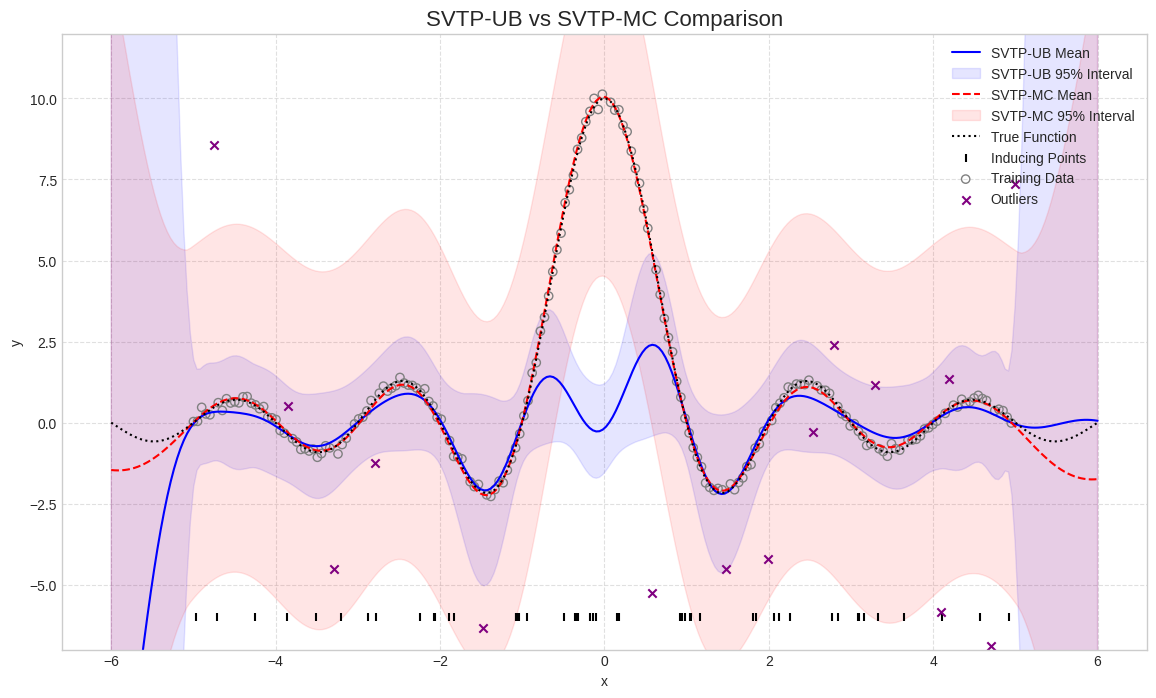

In [58]:
import torch
import torch.nn as nn
from torch.distributions import StudentT, Gamma
import math
import copy
import matplotlib.pyplot as plt
import tqdm

# # For reproducibility
# torch.manual_seed(1234)
# torch.set_default_dtype(torch.float64)

# ═══ 1. Helper Function for Student-t Log-PDF ══════════════════════

def logpdf_st(x, mu, K, nu):
    """
    Calculates the log-pdf of a multivariate Student-t distribution.
    This is a Python translation of the Julia helper function.
    """
    d = mu.shape[0]
    K_stable = K + 1e-6 * torch.eye(d, device=K.device)
    L = torch.linalg.cholesky(K_stable)
    log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))

    # --- CORRECTED LINE ---
    # Reshape mu to [d, 1] to allow broadcasting over samples in x ([d, num_samples])
    diff = x - mu.unsqueeze(-1)
    
    # solve_triangular handles the batched solve efficiently
    mahalanobis_dist = torch.sum(torch.square(torch.linalg.solve_triangular(L, diff, upper=False)), dim=0)

    term1 = torch.lgamma((nu + d) / 2) - torch.lgamma(nu / 2)
    term2 = -0.5 * log_det_K - (d / 2) * math.log((nu - 2) * math.pi)
    term3 = -((nu + d) / 2) * torch.log(1 + mahalanobis_dist / (nu - 2))

    return term3.squeeze() + term1 + term2


# ═══ 2. SVTP Model Definition ══════════════════════════════════════

class SVTP(nn.Module):
    def __init__(self, X, y, Z_init):
        super().__init__()
        self.register_buffer('X', X)
        self.register_buffer('y', y)
        self.N, self.D = X.shape[0], X.shape[1] if len(X.shape) > 1 else 1
        self.M = Z_init.shape[0]

        # --- Trainable Parameters ---
        self.Z = nn.Parameter(Z_init)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_sigma_n = nn.Parameter(torch.log(torch.tensor(0.1)))
        self.log_nu_lik_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))
        self.log_nu_prior_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))
        self.mu_q = nn.Parameter(torch.zeros(self.M))
        self.S_chol_q = nn.Parameter(torch.eye(self.M))
        self.log_nu_q_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))

    def _get_params(self):
        """Helper to get positive parameters from their transformed storage."""
        nu_prior = torch.exp(self.log_nu_prior_minus_2) + 2.0
        nu_q = torch.exp(self.log_nu_q_minus_2) + 2.0
        nu_lik = torch.exp(self.log_nu_lik_minus_2) + 2.0
        sigma_n = torch.exp(self.log_sigma_n)
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        return nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance

    def kernel(self, A, B, variance, lengthscale):
        sq_dist = torch.cdist(A.view(-1, self.D), B.view(-1, self.D), p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def sample_q_u(self, nu_q, num_samples=1):
        r_inv_dist = Gamma(nu_q / 2, 0.5)
        r_inv = r_inv_dist.sample((num_samples,))
        r = 1.0 / r_inv
        eps = torch.randn(self.M, num_samples, device=self.X.device)
        u_samples = self.mu_q.unsqueeze(1) + self.S_chol_q @ (eps * torch.sqrt(r).T)
        return u_samples

    def kl_divergence(self, K_mm, S_q, nu_prior, nu_q, method='UB'):
        if method == 'MC':
            u_samples = self.sample_q_u(nu_q, num_samples=10)
            log_q_u = logpdf_st(u_samples, self.mu_q, S_q, nu_q)
            log_p_u = logpdf_st(u_samples, torch.zeros(self.M, device=self.X.device), K_mm, nu_prior)
            return torch.mean(log_q_u - log_p_u)
        
        elif method == 'UB':
            K_mm_inv = torch.inverse(K_mm)
            l1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)
            tr_term = torch.trace(K_mm_inv @ S_q)
            mean_term = self.mu_q.T @ K_mm_inv @ self.mu_q
            l2_star = torch.log(1 + (tr_term + mean_term) / (nu_prior - 2))
            logdet_S = 2 * torch.sum(torch.log(torch.diag(self.S_chol_q)))
            sign, logdet_K = torch.linalg.slogdet(K_mm)
            if sign.item() <= 0: return float('inf')
            
            C = 0.5 * (logdet_S - logdet_K + self.M * torch.log((nu_prior - 2) / (nu_q - 2)))
            kl_approx = C - ((nu_q + self.M) / 2) * l1 + ((nu_prior + self.M) / 2) * l2_star
            return kl_approx

    def expected_log_likelihood(self, X_batch, y_batch, K_mm_inv, K_nm, nu_lik, sigma_n, num_samples=1):
        nu_prior, nu_q, *_ = self._get_params()
        u_samples = self.sample_q_u(nu_q, num_samples)
        f_est_samples = K_nm @ K_mm_inv @ u_samples
        dist = StudentT(df=nu_lik)
        log_p_y_given_f = dist.log_prob((y_batch.unsqueeze(1) - f_est_samples) / sigma_n) - torch.log(sigma_n)
        return torch.mean(torch.sum(log_p_y_given_f, dim=0))

    def elbo(self, X_batch, y_batch, kl_method='UB', num_samples=1):
        nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance = self._get_params()
        S_q = self.S_chol_q @ self.S_chol_q.T + 1e-6 * torch.eye(self.M, device=self.X.device)
        K_mm = self.kernel(self.Z, self.Z, variance, lengthscale) + 1e-6 * torch.eye(self.M, device=self.X.device)
        K_nm = self.kernel(X_batch, self.Z, variance, lengthscale)
        K_mm_inv = torch.inverse(K_mm)

        kl = self.kl_divergence(K_mm, S_q, nu_prior, nu_q, method=kl_method)
        exp_log_lik = self.expected_log_likelihood(X_batch, y_batch, K_mm_inv, K_nm, nu_lik, sigma_n, num_samples)
        
        scale = self.N / X_batch.shape[0]
        return scale * exp_log_lik - kl

    def fit(self, epochs, optimizer, kl_method='UB', batch_size=128, num_samples=1):
        data_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(self.X, self.y), batch_size=batch_size, shuffle=True)
        print(f"🚀 Starting training with method: {kl_method}")
        pbar = tqdm.trange(epochs)
        for epoch in pbar:
            for x_batch, y_batch in data_loader:
                optimizer.zero_grad()
                neg_elbo = -self.elbo(x_batch, y_batch, kl_method=kl_method, num_samples=num_samples)
                if not (torch.isnan(neg_elbo) or torch.isinf(neg_elbo)):
                    neg_elbo.backward()
                    optimizer.step()
            
            if epoch % 200 == 0:
                nu_p, nu_q, nu_l, *_ = self._get_params()
                pbar.set_description(f"Epoch {epoch:4d} | -ELBO: {neg_elbo.item():.2f} | ν: {nu_p.item():.2f} | ν̃: {nu_q.item():.2f} | ν_lik: {nu_l.item():.2f}")
        print(f"✓ Training complete for method: {kl_method}")

    def predict(self, X_star, num_samples=500):
        """Predicts mean and variance at new points X_star."""
        with torch.no_grad():
            nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance = self._get_params()
            
            K_mm = self.kernel(self.Z, self.Z, variance, lengthscale) + 1e-6 * torch.eye(self.M, device=self.X.device)
            K_star_m = self.kernel(X_star, self.Z, variance, lengthscale)
            K_star_star_diag = torch.diag(self.kernel(X_star, X_star, variance, lengthscale))
            K_mm_inv = torch.inverse(K_mm)
            
            u_samples = self.sample_q_u(nu_q, num_samples=num_samples)
            
            # Shape: [N_test, num_samples]
            f_star_mean_samples = K_star_m @ K_mm_inv @ u_samples
            
            # --- Corrected Variance Calculation ---
            # Shape: [num_samples]
            beta = torch.sum((u_samples.T @ K_mm_inv) * u_samples.T, dim=1)
            # Shape: [num_samples]
            scale_factor = (nu_prior + beta - 2) / (nu_prior + self.M - 2)
            
            # Shape: [N_test]
            K_star_m_K_inv = K_star_m @ K_mm_inv
            var_f_cond_u_diag = K_star_star_diag - torch.sum(K_star_m_K_inv * K_star_m, dim=1)

            # --- CORRECTED LINE ---
            # Use broadcasting: [N_test, 1] * [1, num_samples] -> [N_test, num_samples]
            f_star_var_samples = var_f_cond_u_diag.clamp(min=1e-6).unsqueeze(1) * scale_factor.unsqueeze(0)
            
            # Now all shapes align correctly
            mu_pred = torch.mean(f_star_mean_samples, dim=1)
            var_f_total = torch.mean(f_star_var_samples, dim=1) + torch.var(f_star_mean_samples, dim=1)
            
            # Add variance from the Student-t likelihood
            var_likelihood = (sigma_n**2 * nu_lik) / (nu_lik - 2)
            var_pred = var_f_total + var_likelihood

            return mu_pred, var_pred

# ═══ 3. Example Usage ══════════════════════════════════════════════

if __name__ == '__main__':
    N = 200; M = 50
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    def f_true(x): return torch.sinc(x) * 10
    y_train = f_true(X_train) + torch.randn(N, 1) * 0.1
    
    outlier_indices = torch.randperm(N)[:N//10]
    y_train[outlier_indices] += torch.randn(len(outlier_indices), 1) * 5
    y_train = y_train.squeeze()

    Z_init = X_train[torch.randperm(N)[:M]].clone()

    initial_model = SVTP(X_train, y_train, Z_init)

    model_ub = copy.deepcopy(initial_model)
    optimizer_ub = torch.optim.Adam(model_ub.parameters(), lr=0.01)
    model_ub.fit(5000, optimizer_ub, kl_method='UB', batch_size=1024)

    model_mc = copy.deepcopy(initial_model)
    optimizer_mc = torch.optim.Adam(model_mc.parameters(), lr=0.01)
    model_mc.fit(3000, optimizer_mc, kl_method='MC', batch_size=1024)

    X_test = torch.linspace(-6, 6, 300).unsqueeze(1)
    mu_ub, var_ub = model_ub.predict(X_test)
    std_ub = torch.sqrt(var_ub)
    mu_mc, var_mc = model_mc.predict(X_test)
    std_mc = torch.sqrt(var_mc)

    plt.figure(figsize=(14, 8))
    plt.title("SVTP-UB vs SVTP-MC Comparison", fontsize=16)
    
    plt.plot(X_test, mu_ub, color='blue', label="SVTP-UB Mean")
    plt.fill_between(X_test.squeeze(), mu_ub - 2*std_ub, mu_ub + 2*std_ub, color='blue', alpha=0.1, label="SVTP-UB 95% Interval")
    plt.plot(X_test, mu_mc, color='red', linestyle='--', label="SVTP-MC Mean")
    plt.fill_between(X_test.squeeze(), mu_mc - 2*std_mc, mu_mc + 2*std_mc, color='red', alpha=0.1, label="SVTP-MC 95% Interval")
    
    plt.plot(X_test, f_true(X_test), 'k', linestyle=':', label="True Function")
    plt.scatter(model_ub.Z.detach(), torch.full_like(model_ub.Z.detach(), -6), marker='|', color='black', label="Inducing Points")
    
    non_outliers = torch.ones(N, dtype=torch.bool); non_outliers[outlier_indices] = False
    
    plt.scatter(X_train[non_outliers], y_train[non_outliers], marker='o', facecolors='none', edgecolors='gray', label="Training Data")
    plt.scatter(X_train[outlier_indices], y_train[outlier_indices], marker='x', color='purple', label="Outliers")
    
    plt.xlabel("x"); plt.ylabel("y"); plt.ylim(-7, 12); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

🚀 Starting training with method: UB


Epoch 2800 | -ELBO: -685.02 | ν: 2.01 | ν̃: 202.01 | ν_lik: 2.01: 100%|██████████| 3000/3000 [00:13<00:00, 219.18it/s]


✓ Training complete for method: UB
🚀 Starting training with method: MC


Epoch 2400 | -ELBO: -144.73 | ν: 8.00 | ν̃: 208.00 | ν_lik: 2.04:  81%|████████▏ | 2443/3000 [00:14<00:03, 169.34it/s]

Epoch 2800 | -ELBO: -189.25 | ν: 7.98 | ν̃: 207.98 | ν_lik: 2.03: 100%|██████████| 3000/3000 [00:17<00:00, 167.46it/s]


✓ Training complete for method: MC


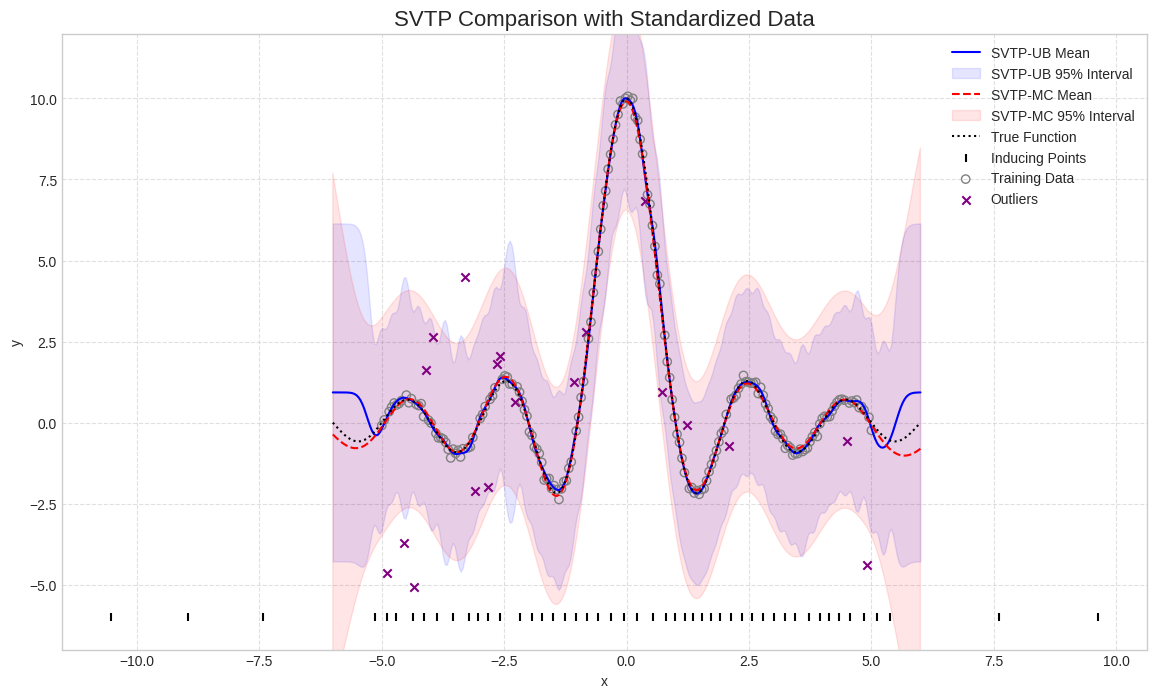

In [67]:
import torch
import torch.nn as nn
from torch.distributions import StudentT, Gamma
import math
import copy
import matplotlib.pyplot as plt
import tqdm

# # For reproducibility
# torch.manual_seed(1234)
torch.set_default_dtype(torch.float64)

# ═══ 1. Helper Function for Student-t Log-PDF ══════════════════════

def logpdf_st(x, mu, K, nu):
    """
    Calculates the log-pdf of a multivariate Student-t distribution.
    """
    d = mu.shape[0]
    K_stable = K + 1e-6 * torch.eye(d, device=K.device)
    L = torch.linalg.cholesky(K_stable)
    log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))

    diff = x - mu.unsqueeze(-1)
    mahalanobis_dist = torch.sum(torch.square(torch.linalg.solve_triangular(L, diff, upper=False)), dim=0)

    term1 = torch.lgamma((nu + d) / 2) - torch.lgamma(nu / 2)
    term2 = -0.5 * log_det_K - (d / 2) * math.log((nu - 2) * math.pi)
    term3 = -((nu + d) / 2) * torch.log(1 + mahalanobis_dist / (nu - 2))

    return term3.squeeze() + term1 + term2


# ═══ 2. SVTP Model Definition ══════════════════════════════════════

class SVTP(nn.Module):
    def __init__(self, X, y, Z_init):
        super().__init__()
        self.register_buffer('X', X)
        self.register_buffer('y', y)
        self.N, self.D = X.shape[0], X.shape[1] if len(X.shape) > 1 else 1
        self.M = Z_init.shape[0]

        # --- Trainable Parameters ---
        self.Z = nn.Parameter(Z_init)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_sigma_n = nn.Parameter(torch.log(torch.tensor(0.1)))
        self.log_nu_lik_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))
        self.log_nu_prior_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))
        self.mu_q = nn.Parameter(torch.zeros(self.M))
        self.S_chol_q = nn.Parameter(torch.eye(self.M))
        
        # REMOVED: self.log_nu_q_minus_2 is no longer a free parameter.

    def _get_params(self):
        """Helper to get positive parameters from their transformed storage."""
        nu_prior = torch.exp(self.log_nu_prior_minus_2) + 2.0
        
        # MODIFIED: nu_q is now determined by nu_prior and N, per the paper's finding.
        nu_q = nu_prior + self.N
        
        nu_lik = torch.exp(self.log_nu_lik_minus_2) + 2.0
        sigma_n = torch.exp(self.log_sigma_n)
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        return nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance

    def kernel(self, A, B, variance, lengthscale):
        sq_dist = torch.cdist(A.view(-1, self.D), B.view(-1, self.D), p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def sample_q_u(self, nu_q, num_samples=1):
        r_inv_dist = Gamma(nu_q / 2, 0.5)
        r_inv = r_inv_dist.sample((num_samples,))
        r = 1.0 / r_inv
        eps = torch.randn(self.M, num_samples, device=self.X.device)
        u_samples = self.mu_q.unsqueeze(1) + self.S_chol_q @ (eps * torch.sqrt(r).T)
        return u_samples

    # def kl_divergence(self, K_mm, S_q, nu_prior, nu_q, method='UB'):
    #     if method == 'MC':
    #         u_samples = self.sample_q_u(nu_q, num_samples=10)
    #         log_q_u = logpdf_st(u_samples, self.mu_q, S_q, nu_q)
    #         log_p_u = logpdf_st(u_samples, torch.zeros(self.M, device=self.X.device), K_mm, nu_prior)
    #         return torch.mean(log_q_u - log_p_u)
        
    #     elif method == 'UB':
    #         # --- Debugging Helper ---
    #         def check(tensor, name):
    #             if torch.isnan(tensor).any() or torch.isinf(tensor).any():
    #                 print(f"DEBUG: Problem detected in '{name}'. Value: {tensor.item()}")
    #                 # Return a dummy value to propagate the nan and stop the backward pass
    #                 return True
    #             return False

    #         # --- Calculation with Checks ---
    #         try:
    #             K_mm_inv = torch.inverse(K_mm)
    #             if check(K_mm_inv.sum(), 'K_mm_inv'): return torch.tensor(float('nan'))
    #         except torch.linalg.LinAlgError:
    #             print("DEBUG: K_mm is singular and cannot be inverted.")
    #             return torch.tensor(float('nan'))

    #         l1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)
    #         if check(l1, 'l1'): return torch.tensor(float('nan'))

    #         tr_term = torch.trace(K_mm_inv @ S_q)
    #         if check(tr_term, 'tr_term'): return torch.tensor(float('nan'))

    #         mean_term = self.mu_q.T @ K_mm_inv @ self.mu_q
    #         if check(mean_term, 'mean_term'): return torch.tensor(float('nan'))
            
    #         # Specifically check the argument to the log, a common source of NaNs
    #         l2_star_arg = 1 + (tr_term + mean_term) / (nu_prior - 2)
    #         if check(l2_star_arg, 'Argument to log for l2_star'): return torch.tensor(float('nan'))
    #         if l2_star_arg <= 0:
    #             print(f"DEBUG: Non-positive argument for log in l2_star. Value: {l2_star_arg.item()}")
    #             return torch.tensor(float('nan'))
            
    #         l2_star = torch.log(l2_star_arg)
    #         if check(l2_star, 'l2_star'): return torch.tensor(float('nan'))

    #         logdet_S = 2 * torch.sum(torch.log(torch.diag(self.S_chol_q)))
    #         if check(logdet_S, 'logdet_S'): return torch.tensor(float('nan'))

    #         sign, logdet_K = torch.linalg.slogdet(K_mm)
    #         if sign.item() <= 0: 
    #             print(f"DEBUG: K_mm matrix is not positive definite. Sign of logdet: {sign.item()}")
    #             return torch.tensor(float('inf'))
    #         if check(logdet_K, 'logdet_K'): return torch.tensor(float('nan'))
            
    #         log_nu_diff = torch.log(nu_prior - 2) - torch.log(nu_q - 2)
    #         if check(log_nu_diff, 'log_nu_diff'): return torch.tensor(float('nan'))
            
    #         C = 0.5 * (logdet_S - logdet_K + self.M * log_nu_diff)
    #         if check(C, 'C'): return torch.tensor(float('nan'))

    #         kl_approx = C - ((nu_q + self.M) / 2) * l1 + ((nu_prior + self.M) / 2) * l2_star
    #         if check(kl_approx, 'kl_approx (final)'): return torch.tensor(float('nan'))
            
    #         return kl_approx

    def kl_divergence(self, K_mm, S_q, nu_prior, nu_q, method='UB'):
        """Calculates the KL divergence term KL(q(u) || p(u))."""
        if method == 'MC':
            u_samples = self.sample_q_u(nu_q, num_samples=10)
            log_q_u = logpdf_st(u_samples, self.mu_q, S_q, nu_q)
            log_p_u = logpdf_st(u_samples, torch.zeros(self.M, device=self.X.device), K_mm, nu_prior)
            return torch.mean(log_q_u - log_p_u)
        
        elif method == 'UB':
            K_mm_inv = torch.inverse(K_mm)
            
            # L1 term
            l1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)
            
            # L2* term
            tr_term = torch.trace(K_mm_inv @ S_q)
            mean_term = self.mu_q.T @ K_mm_inv @ self.mu_q
            l2_star = torch.log(1 + (tr_term + mean_term) / (nu_prior - 2))
            
            # --- CORRECTED LOG-DETERMINANT CALCULATION ---
            # Calculate logdet from the guaranteed positive-definite S_q matrix, not the raw parameter
            sign_S, logdet_S = torch.linalg.slogdet(S_q)
            if sign_S.item() <= 0: return float('inf')

            sign_K, logdet_K = torch.linalg.slogdet(K_mm)
            if sign_K.item() <= 0: return float('inf')
            
            # The term (nu_q - 2) must be handled carefully as nu_q can be large
            log_nu_diff = torch.log(nu_prior - 2) - torch.log(nu_q - 2)
            
            C = 0.5 * (logdet_S - logdet_K + self.M * log_nu_diff)
            kl_approx = C - ((nu_q + self.M) / 2) * l1 + ((nu_prior + self.M) / 2) * l2_star
            return kl_approx

    def expected_log_likelihood(self, X_batch, y_batch, K_mm_inv, K_nm, nu_q, nu_lik, sigma_n, num_samples=1):
        u_samples = self.sample_q_u(nu_q, num_samples)
        f_est_samples = K_nm @ K_mm_inv @ u_samples
        dist = StudentT(df=nu_lik)
        log_p_y_given_f = dist.log_prob((y_batch.unsqueeze(1) - f_est_samples) / sigma_n) - torch.log(sigma_n)
        return torch.mean(torch.sum(log_p_y_given_f, dim=0))

    def elbo(self, X_batch, y_batch, kl_method='UB', num_samples=1):
        nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance = self._get_params()
        S_q = self.S_chol_q @ self.S_chol_q.T + 1e-6 * torch.eye(self.M, device=self.X.device)
        K_mm = self.kernel(self.Z, self.Z, variance, lengthscale) + 1e-6 * torch.eye(self.M, device=self.X.device)
        K_nm = self.kernel(X_batch, self.Z, variance, lengthscale)
        K_mm_inv = torch.inverse(K_mm)

        kl = self.kl_divergence(K_mm, S_q, nu_prior, nu_q, method=kl_method)
        exp_log_lik = self.expected_log_likelihood(X_batch, y_batch, K_mm_inv, K_nm, nu_q, nu_lik, sigma_n, num_samples)
        
        scale = self.N / X_batch.shape[0]
        return scale * exp_log_lik - kl

    def fit(self, epochs, optimizer, kl_method='UB', batch_size=128, num_samples=1):
        data_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(self.X, self.y), batch_size=batch_size, shuffle=True)
        print(f"🚀 Starting training with method: {kl_method}")
        pbar = tqdm.trange(epochs)
        for epoch in pbar:
            for x_batch, y_batch in data_loader:
                optimizer.zero_grad()
                neg_elbo = -self.elbo(x_batch, y_batch, kl_method=kl_method, num_samples=num_samples)
                if not (torch.isnan(neg_elbo) or torch.isinf(neg_elbo)):
                    neg_elbo.backward()
                    optimizer.step()
            
            if epoch % 200 == 0:
                nu_p, nu_q, nu_l, *_ = self._get_params()
                pbar.set_description(f"Epoch {epoch:4d} | -ELBO: {neg_elbo.item():.2f} | ν: {nu_p.item():.2f} | ν̃: {nu_q.item():.2f} | ν_lik: {nu_l.item():.2f}")
        print(f"✓ Training complete for method: {kl_method}")

    def predict(self, X_star, num_samples=500):
        with torch.no_grad():
            nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance = self._get_params()
            K_mm = self.kernel(self.Z, self.Z, variance, lengthscale) + 1e-6 * torch.eye(self.M, device=self.X.device)
            K_star_m = self.kernel(X_star, self.Z, variance, lengthscale)
            K_star_star_diag = torch.diag(self.kernel(X_star, X_star, variance, lengthscale))
            K_mm_inv = torch.inverse(K_mm)
            
            u_samples = self.sample_q_u(nu_q, num_samples=num_samples)
            f_star_mean_samples = K_star_m @ K_mm_inv @ u_samples
            
            beta = torch.sum((u_samples.T @ K_mm_inv) * u_samples.T, dim=1)
            scale_factor = (nu_prior + beta - 2) / (nu_prior + self.M - 2)
            
            K_star_m_K_inv = K_star_m @ K_mm_inv
            var_f_cond_u_diag = K_star_star_diag - torch.sum(K_star_m_K_inv * K_star_m, dim=1)
            f_star_var_samples = var_f_cond_u_diag.clamp(min=1e-6).unsqueeze(1) * scale_factor.unsqueeze(0)
            
            mu_pred = torch.mean(f_star_mean_samples, dim=1)
            var_f_total = torch.mean(f_star_var_samples, dim=1) + torch.var(f_star_mean_samples, dim=1)
            var_likelihood = (sigma_n**2 * nu_lik) / (nu_lik - 2)
            var_pred = var_f_total + var_likelihood
            return mu_pred, var_pred

# ═══ 3. Example Usage with Standardization ══════════════════════════

if __name__ == '__main__':
    # --- Generate Original Data ---
    N = 200; M = 50
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    def f_true(x): return torch.sinc(x) * 10
    y_train_orig = f_true(X_train) + torch.randn(N, 1) * 0.1
    
    outlier_indices = torch.randperm(N)[:N//10]
    y_train_orig[outlier_indices] += torch.randn(len(outlier_indices), 1) * 5
    y_train_orig = y_train_orig.squeeze()

    # --- Standardize Data ---
    x_mean, x_std = X_train.mean(), X_train.std()
    y_mean, y_std = y_train_orig.mean(), y_train_orig.std()

    X_train_std = (X_train - x_mean) / x_std
    y_train_std = (y_train_orig - y_mean) / y_std
    
    # Initialize inducing points from the standardized data
    Z_init_std = X_train_std[torch.randperm(N)[:M]].clone()

    # --- Create Initial Model using Standardized Data ---
    initial_model = SVTP(X_train_std, y_train_std, Z_init_std)

    # --- Train Models ---
    model_ub = copy.deepcopy(initial_model)
    optimizer_ub = torch.optim.Adam(model_ub.parameters(), lr=0.01)
    model_ub.fit(3000, optimizer_ub, kl_method='UB', batch_size=1024)

    model_mc = copy.deepcopy(initial_model)
    optimizer_mc = torch.optim.Adam(model_mc.parameters(), lr=0.01)
    model_mc.fit(3000, optimizer_mc, kl_method='MC', batch_size=1024)

    # --- Generate and Standardize Test Data ---
    X_test = torch.linspace(-6, 6, 300).unsqueeze(1)
    X_test_std = (X_test - x_mean) / x_std
    
    # --- Get Predictions in Standardized Space ---
    mu_ub_std, var_ub_std = model_ub.predict(X_test_std)
    mu_mc_std, var_mc_std = model_mc.predict(X_test_std)

    # --- Un-standardize Predictions for Plotting ---
    mu_ub = mu_ub_std * y_std + y_mean
    std_ub = torch.sqrt(var_ub_std) * y_std
    
    mu_mc = mu_mc_std * y_std + y_mean
    std_mc = torch.sqrt(var_mc_std) * y_std

    # --- Un-standardize Inducing Points for Plotting ---
    Z_ub_unstd = model_ub.Z.detach() * x_std + x_mean

    # --- Plotting on Original Scale ---
    plt.figure(figsize=(14, 8))
    plt.title("SVTP Comparison with Standardized Data", fontsize=16)
    
    plt.plot(X_test, mu_ub, color='blue', label="SVTP-UB Mean")
    plt.fill_between(X_test.squeeze(), mu_ub - 2*std_ub, mu_ub + 2*std_ub, color='blue', alpha=0.1, label="SVTP-UB 95% Interval")
    
    plt.plot(X_test, mu_mc, color='red', linestyle='--', label="SVTP-MC Mean")
    plt.fill_between(X_test.squeeze(), mu_mc - 2*std_mc, mu_mc + 2*std_mc, color='red', alpha=0.1, label="SVTP-MC 95% Interval")
    
    plt.plot(X_test, f_true(X_test), 'k', linestyle=':', label="True Function")
    plt.scatter(Z_ub_unstd, torch.full_like(Z_ub_unstd, -6), marker='|', color='black', label="Inducing Points")
    
    non_outliers = torch.ones(N, dtype=torch.bool); non_outliers[outlier_indices] = False
    
    plt.scatter(X_train[non_outliers], y_train_orig[non_outliers], marker='o', facecolors='none', edgecolors='gray', label="Training Data")
    plt.scatter(X_train[outlier_indices], y_train_orig[outlier_indices], marker='x', color='purple', label="Outliers")
    
    plt.xlabel("x"); plt.ylabel("y"); plt.ylim(-7, 12); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

🚀 Starting training with method: UB


Epoch  800 | -ELBO: nan | ν: 2.31 | ν̃: 6.46 | ν_lik: 2.53: 100%|██████████| 1000/1000 [00:06<00:00, 149.57it/s]   


✓ Training complete for method: UB
🚀 Starting training with method: MC


Epoch  800 | -ELBO: 304.00 | ν: 6.87 | ν̃: 2.00 | ν_lik: 2.24: 100%|██████████| 1000/1000 [00:10<00:00, 91.40it/s]


✓ Training complete for method: MC


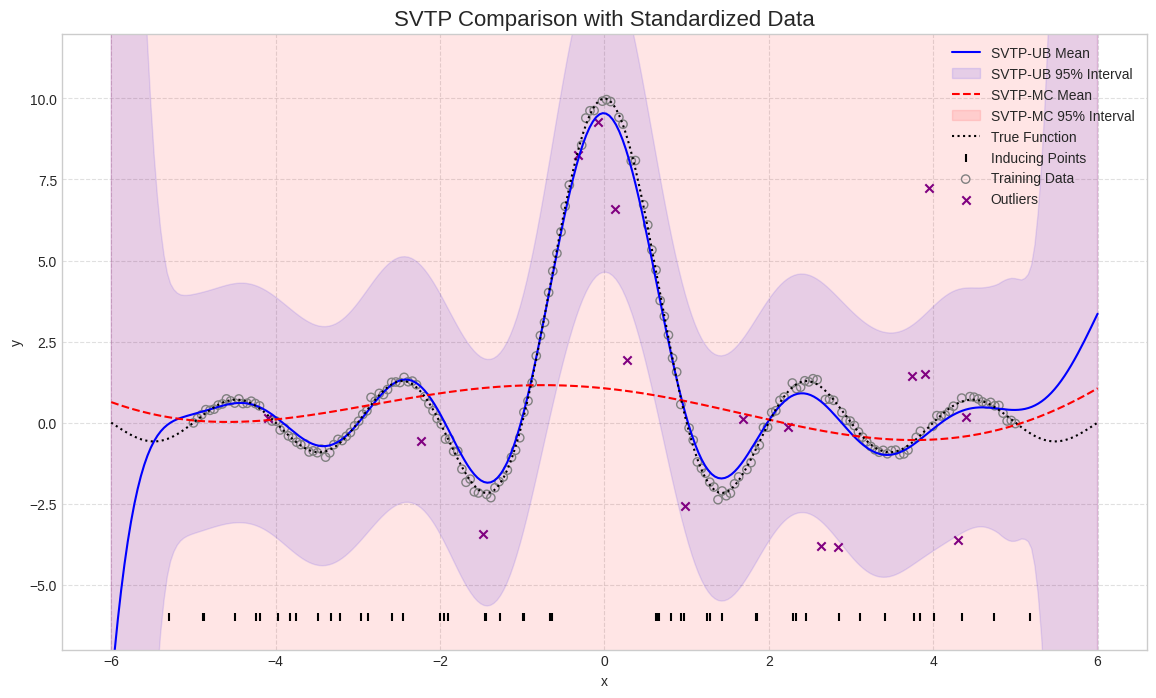

In [62]:
import torch
import torch.nn as nn
from torch.distributions import StudentT, Gamma
import math
import copy
import matplotlib.pyplot as plt
import tqdm

# For reproducibility
torch.manual_seed(1234)
torch.set_default_dtype(torch.float64)

# ═══ 1. Helper Function for Student-t Log-PDF ══════════════════════

def logpdf_st(x, mu, K, nu):
    """
    Calculates the log-pdf of a multivariate Student-t distribution.
    """
    d = mu.shape[0]
    K_stable = K + 1e-6 * torch.eye(d, device=K.device)
    L = torch.linalg.cholesky(K_stable)
    log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))

    # Reshape mu to [d, 1] to allow broadcasting over samples in x ([d, num_samples])
    diff = x - mu.unsqueeze(-1)
    
    # solve_triangular handles the batched solve efficiently
    mahalanobis_dist = torch.sum(torch.square(torch.linalg.solve_triangular(L, diff, upper=False)), dim=0)

    term1 = torch.lgamma((nu + d) / 2) - torch.lgamma(nu / 2)
    term2 = -0.5 * log_det_K - (d / 2) * math.log((nu - 2) * math.pi)
    term3 = -((nu + d) / 2) * torch.log(1 + mahalanobis_dist / (nu - 2))

    return term3.squeeze() + term1 + term2


# ═══ 2. SVTP Model Definition ══════════════════════════════════════

class SVTP(nn.Module):
    def __init__(self, X, y, Z_init):
        super().__init__()
        self.register_buffer('X', X)
        self.register_buffer('y', y)
        self.N, self.D = X.shape[0], X.shape[1] if len(X.shape) > 1 else 1
        self.M = Z_init.shape[0]

        # --- Trainable Parameters ---
        self.Z = nn.Parameter(Z_init)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_sigma_n = nn.Parameter(torch.log(torch.tensor(0.1)))
        self.log_nu_lik_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))
        self.log_nu_prior_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))
        self.mu_q = nn.Parameter(torch.zeros(self.M))
        self.S_chol_q = nn.Parameter(torch.eye(self.M))
        self.log_nu_q_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))

    def _get_params(self):
        """Helper to get positive parameters from their transformed storage."""
        nu_prior = torch.exp(self.log_nu_prior_minus_2) + 2.0
        nu_q = torch.exp(self.log_nu_q_minus_2) + 2.0
        nu_lik = torch.exp(self.log_nu_lik_minus_2) + 2.0
        sigma_n = torch.exp(self.log_sigma_n)
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        return nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance

    def kernel(self, A, B, variance, lengthscale):
        sq_dist = torch.cdist(A.view(-1, self.D), B.view(-1, self.D), p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def sample_q_u(self, nu_q, num_samples=1):
        r_inv_dist = Gamma(nu_q / 2, 0.5)
        r_inv = r_inv_dist.sample((num_samples,))
        r = 1.0 / r_inv
        eps = torch.randn(self.M, num_samples, device=self.X.device)
        u_samples = self.mu_q.unsqueeze(1) + self.S_chol_q @ (eps * torch.sqrt(r).T)
        return u_samples

    def kl_divergence(self, K_mm, S_q, nu_prior, nu_q, method='UB'):
        if method == 'MC':
            u_samples = self.sample_q_u(nu_q, num_samples=10)
            log_q_u = logpdf_st(u_samples, self.mu_q, S_q, nu_q)
            log_p_u = logpdf_st(u_samples, torch.zeros(self.M, device=self.X.device), K_mm, nu_prior)
            return torch.mean(log_q_u - log_p_u)
        
        elif method == 'UB':
            K_mm_inv = torch.inverse(K_mm)
            l1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)
            tr_term = torch.trace(K_mm_inv @ S_q)
            mean_term = self.mu_q.T @ K_mm_inv @ self.mu_q
            l2_star = torch.log(1 + (tr_term + mean_term) / (nu_prior - 2))
            logdet_S = 2 * torch.sum(torch.log(torch.diag(self.S_chol_q)))
            sign, logdet_K = torch.linalg.slogdet(K_mm)
            if sign.item() <= 0: return float('inf')
            
            C = 0.5 * (logdet_S - logdet_K + self.M * torch.log((nu_prior - 2) / (nu_q - 2)))
            kl_approx = C - ((nu_q + self.M) / 2) * l1 + ((nu_prior + self.M) / 2) * l2_star
            return kl_approx

    def expected_log_likelihood(self, X_batch, y_batch, K_mm_inv, K_nm, nu_lik, sigma_n, num_samples=1):
        nu_prior, nu_q, *_ = self._get_params()
        u_samples = self.sample_q_u(nu_q, num_samples)
        f_est_samples = K_nm @ K_mm_inv @ u_samples
        dist = StudentT(df=nu_lik)
        log_p_y_given_f = dist.log_prob((y_batch.unsqueeze(1) - f_est_samples) / sigma_n) - torch.log(sigma_n)
        return torch.mean(torch.sum(log_p_y_given_f, dim=0))

    def elbo(self, X_batch, y_batch, kl_method='UB', num_samples=1):
        nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance = self._get_params()
        S_q = self.S_chol_q @ self.S_chol_q.T + 1e-6 * torch.eye(self.M, device=self.X.device)
        K_mm = self.kernel(self.Z, self.Z, variance, lengthscale) + 1e-6 * torch.eye(self.M, device=self.X.device)
        K_nm = self.kernel(X_batch, self.Z, variance, lengthscale)
        K_mm_inv = torch.inverse(K_mm)

        kl = self.kl_divergence(K_mm, S_q, nu_prior, nu_q, method=kl_method)
        exp_log_lik = self.expected_log_likelihood(X_batch, y_batch, K_mm_inv, K_nm, nu_lik, sigma_n, num_samples)
        
        scale = self.N / X_batch.shape[0]
        return scale * exp_log_lik - kl

    def fit(self, epochs, optimizer, kl_method='UB', batch_size=128, num_samples=1):
        data_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(self.X, self.y), batch_size=batch_size, shuffle=True)
        print(f"🚀 Starting training with method: {kl_method}")
        pbar = tqdm.trange(epochs)
        for epoch in pbar:
            for x_batch, y_batch in data_loader:
                optimizer.zero_grad()
                neg_elbo = -self.elbo(x_batch, y_batch, kl_method=kl_method, num_samples=num_samples)
                if not (torch.isnan(neg_elbo) or torch.isinf(neg_elbo)):
                    neg_elbo.backward()
                    optimizer.step()
            
            if epoch % 200 == 0:
                nu_p, nu_q, nu_l, *_ = self._get_params()
                pbar.set_description(f"Epoch {epoch:4d} | -ELBO: {neg_elbo.item():.2f} | ν: {nu_p.item():.2f} | ν̃: {nu_q:.2f} | ν_lik: {nu_l.item():.2f}")
        print(f"✓ Training complete for method: {kl_method}")

    def predict(self, X_star, num_samples=500):
        with torch.no_grad():
            nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance = self._get_params()
            K_mm = self.kernel(self.Z, self.Z, variance, lengthscale) + 1e-6 * torch.eye(self.M, device=self.X.device)
            K_star_m = self.kernel(X_star, self.Z, variance, lengthscale)
            K_star_star_diag = torch.diag(self.kernel(X_star, X_star, variance, lengthscale))
            K_mm_inv = torch.inverse(K_mm)
            
            u_samples = self.sample_q_u(nu_q, num_samples=num_samples)
            f_star_mean_samples = K_star_m @ K_mm_inv @ u_samples
            
            beta = torch.sum((u_samples.T @ K_mm_inv) * u_samples.T, dim=1)
            scale_factor = (nu_prior + beta - 2) / (nu_prior + self.M - 2)
            
            K_star_m_K_inv = K_star_m @ K_mm_inv
            var_f_cond_u_diag = K_star_star_diag - torch.sum(K_star_m_K_inv * K_star_m, dim=1)
            f_star_var_samples = var_f_cond_u_diag.clamp(min=1e-6).unsqueeze(1) * scale_factor.unsqueeze(0)
            
            mu_pred = torch.mean(f_star_mean_samples, dim=1)
            var_f_total = torch.mean(f_star_var_samples, dim=1) + torch.var(f_star_mean_samples, dim=1)
            var_likelihood = (sigma_n**2 * nu_lik) / (nu_lik - 2)
            var_pred = var_f_total + var_likelihood
            return mu_pred, var_pred

# ═══ 3. Example Usage with Standardization ══════════════════════════

if __name__ == '__main__':
    # --- Generate Original Data ---
    N = 200; M = 50
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    def f_true(x): return torch.sinc(x) * 10
    y_train_orig = f_true(X_train) + torch.randn(N, 1) * 0.1
    
    outlier_indices = torch.randperm(N)[:N//10]
    y_train_orig[outlier_indices] += torch.randn(len(outlier_indices), 1) * 5
    y_train_orig = y_train_orig.squeeze()

    # --- Standardize Data ---
    x_mean, x_std = X_train.mean(), X_train.std()
    y_mean, y_std = y_train_orig.mean(), y_train_orig.std()

    X_train_std = (X_train - x_mean) / x_std
    y_train_std = (y_train_orig - y_mean) / y_std
    
    # Initialize inducing points from the standardized data
    Z_init_std = X_train_std[torch.randperm(N)[:M]].clone()

    # --- Create Initial Model using Standardized Data ---
    initial_model = SVTP(X_train_std, y_train_std, Z_init_std)

    # --- Train Models ---
    model_ub = copy.deepcopy(initial_model)
    optimizer_ub = torch.optim.Adam(model_ub.parameters(), lr=0.01)
    model_ub.fit(1000, optimizer_ub, kl_method='UB', batch_size=128)

    model_mc = copy.deepcopy(initial_model)
    optimizer_mc = torch.optim.Adam(model_mc.parameters(), lr=0.01)
    model_mc.fit(1000, optimizer_mc, kl_method='MC', batch_size=128)

    # --- Generate and Standardize Test Data ---
    X_test = torch.linspace(-6, 6, 300).unsqueeze(1)
    X_test_std = (X_test - x_mean) / x_std
    
    # --- Get Predictions in Standardized Space ---
    mu_ub_std, var_ub_std = model_ub.predict(X_test_std)
    mu_mc_std, var_mc_std = model_mc.predict(X_test_std)

    # --- Un-standardize Predictions for Plotting ---
    mu_ub = mu_ub_std * y_std + y_mean
    std_ub = torch.sqrt(var_ub_std) * y_std
    
    mu_mc = mu_mc_std * y_std + y_mean
    std_mc = torch.sqrt(var_mc_std) * y_std

    # --- Un-standardize Inducing Points for Plotting ---
    Z_ub_unstd = model_ub.Z.detach() * x_std + x_mean

    # --- Plotting on Original Scale ---
    plt.figure(figsize=(14, 8))
    plt.title("SVTP Comparison with Standardized Data", fontsize=16)
    
    plt.plot(X_test, mu_ub, color='blue', label="SVTP-UB Mean")
    plt.fill_between(X_test.squeeze(), mu_ub - 2*std_ub, mu_ub + 2*std_ub, color='blue', alpha=0.1, label="SVTP-UB 95% Interval")
    
    plt.plot(X_test, mu_mc, color='red', linestyle='--', label="SVTP-MC Mean")
    plt.fill_between(X_test.squeeze(), mu_mc - 2*std_mc, mu_mc + 2*std_mc, color='red', alpha=0.1, label="SVTP-MC 95% Interval")
    
    plt.plot(X_test, f_true(X_test), 'k', linestyle=':', label="True Function")
    plt.scatter(Z_ub_unstd, torch.full_like(Z_ub_unstd, -6), marker='|', color='black', label="Inducing Points")
    
    non_outliers = torch.ones(N, dtype=torch.bool); non_outliers[outlier_indices] = False
    
    plt.scatter(X_train[non_outliers], y_train_orig[non_outliers], marker='o', facecolors='none', edgecolors='gray', label="Training Data")
    plt.scatter(X_train[outlier_indices], y_train_orig[outlier_indices], marker='x', color='purple', label="Outliers")
    
    plt.xlabel("x"); plt.ylabel("y"); plt.ylim(-7, 12); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

Using device: cpu
Starting training with method: UB
Epoch:  200 | Loss (-ELBO): 1462.4247 | nu: 2.74 | nu_tilde: 4.05 | nu_lik: 2.81
Epoch:  400 | Loss (-ELBO): 1039.8063 | nu: 2.44 | nu_tilde: 4.74 | nu_lik: 2.61
Epoch:  600 | Loss (-ELBO): 982.7896 | nu: 2.29 | nu_tilde: 5.39 | nu_lik: 2.52
Epoch:  800 | Loss (-ELBO): 954.6528 | nu: 2.22 | nu_tilde: 6.01 | nu_lik: 2.47
Epoch: 1000 | Loss (-ELBO): 950.2510 | nu: 2.17 | nu_tilde: 6.60 | nu_lik: 2.43
Epoch: 1200 | Loss (-ELBO): 933.5541 | nu: 2.14 | nu_tilde: 7.19 | nu_lik: 2.40
Epoch: 1400 | Loss (-ELBO): 908.9970 | nu: 2.13 | nu_tilde: 7.77 | nu_lik: 2.38
Epoch: 1600 | Loss (-ELBO): 918.4710 | nu: 2.12 | nu_tilde: 8.34 | nu_lik: 2.36
Epoch: 1800 | Loss (-ELBO): 954.5257 | nu: 2.12 | nu_tilde: 8.92 | nu_lik: 2.34
Epoch: 2000 | Loss (-ELBO): 962.1615 | nu: 2.11 | nu_tilde: 9.51 | nu_lik: 2.32
Epoch: 2200 | Loss (-ELBO): 965.9312 | nu: 2.11 | nu_tilde: 10.10 | nu_lik: 2.30
Epoch: 2400 | Loss (-ELBO): 926.5962 | nu: 2.11 | nu_tilde: 10.70

Epoch: 3800 | Loss (-ELBO): 824.3136 | nu: 2.12 | nu_tilde: 15.19 | nu_lik: 2.15
Epoch: 4000 | Loss (-ELBO): 738.6576 | nu: 2.12 | nu_tilde: 15.88 | nu_lik: 2.13
Epoch: 4200 | Loss (-ELBO): 497.0370 | nu: 2.23 | nu_tilde: 16.59 | nu_lik: 2.11
Epoch: 4400 | Loss (-ELBO): 484.5877 | nu: 2.26 | nu_tilde: 17.30 | nu_lik: 2.10
Epoch: 4600 | Loss (-ELBO): 465.8105 | nu: 2.26 | nu_tilde: 18.03 | nu_lik: 2.08
Epoch: 4800 | Loss (-ELBO): 458.1683 | nu: 2.26 | nu_tilde: 18.77 | nu_lik: 2.07
Epoch: 5000 | Loss (-ELBO): 414.7127 | nu: 2.26 | nu_tilde: 19.52 | nu_lik: 2.05
Epoch: 5200 | Loss (-ELBO): 411.9583 | nu: 2.26 | nu_tilde: 20.29 | nu_lik: 2.05
Epoch: 5400 | Loss (-ELBO): 411.0464 | nu: 2.26 | nu_tilde: 21.06 | nu_lik: 2.04
Epoch: 5600 | Loss (-ELBO): 386.7910 | nu: 2.26 | nu_tilde: 21.84 | nu_lik: 2.03
Epoch: 5800 | Loss (-ELBO): 398.4842 | nu: 2.26 | nu_tilde: 22.63 | nu_lik: 2.03
Epoch: 6000 | Loss (-ELBO): 389.8785 | nu: 2.26 | nu_tilde: 23.43 | nu_lik: 2.02
Epoch: 6200 | Loss (-ELBO): 

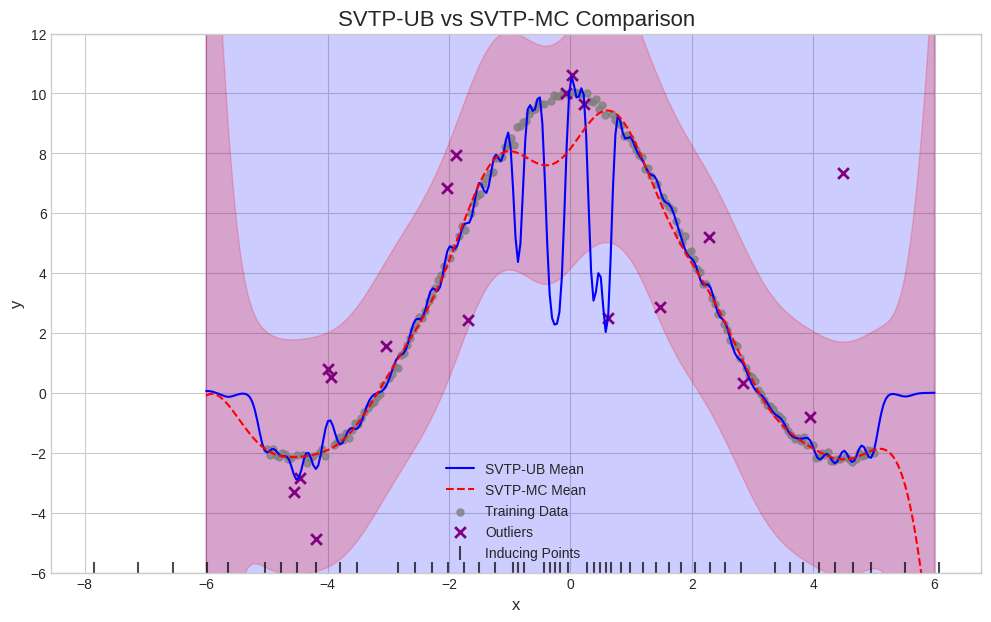

In [55]:
#
# A Python implementation of Sparse Variational Student-t Processes
# based on the paper by Xu and Zeng (2023).
# This version compares the SVTP-UB and SVTP-MC methods.
#

# ========================= 1. Required Packages =========================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Gamma, StudentT, MultivariateNormal
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

# For reproducibility
torch.manual_seed(1234)
np.random.seed(1234)


# ========================= 2. Helper Functions ==========================

def logpdf_st(x, mu, K, nu):
    """
    Calculates the log-pdf of a multivariate Student-t distribution.
    This is based on Definition 1 in the paper.

    Args:
        x: The data point (or batch of points).
        mu: The mean vector (location).
        K: The scale matrix (analogous to covariance).
        nu: The degrees of freedom.
    """
    d = mu.shape[0]
    
    # Add jitter for numerical stability
    K_stable = K + 1e-6 * torch.eye(d, device=K.device)
    L = torch.linalg.cholesky(K_stable)
    log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))

    # Mahalanobis-like distance
    delta = x - mu
    # Solve L @ z = delta for z, then compute sum of squares
    mahalanobis_dist = torch.sum(torch.square(torch.linalg.solve_triangular(L, delta.T, upper=False)), dim=0)

    term1 = torch.lgamma((nu + d) / 2) - torch.lgamma(nu / 2)
    term2 = -0.5 * log_det_K - (d / 2) * torch.log((nu - 2) * math.pi)
    term3 = -((nu + d) / 2) * torch.log(1 + mahalanobis_dist / (nu - 2))

    return term1 + term2 + term3

def squared_exponential_kernel(x1, x2, lengthscale, variance=1.0):
    """Computes the RBF (Squared Exponential) kernel matrix."""
    # The ||x-z||^2 part of the kernel
    sq_dist = torch.sum(x1**2, 1).reshape(-1, 1) + torch.sum(x2**2, 1) - 2 * torch.mm(x1, x2.T)
    # The full kernel
    return variance * torch.exp(-0.5 * sq_dist / lengthscale**2)

# ======================== 3. SVTP Model Definition ========================

class SVTP(nn.Module):
    def __init__(self, X, y, M=50):
        super().__init__()
        self.M = M

        # Fixed data - register as buffers so they are moved to device with the model
        self.register_buffer('X', torch.tensor(X, dtype=torch.float64))
        self.register_buffer('y', torch.tensor(y, dtype=torch.float64))

        # Initialize inducing points by random subsampling
        indices = np.random.choice(X.shape[0], M, replace=False)
        Z_init = self.X[indices, :].clone()
        
        # Inducing points (trainable)
        self.Z = nn.Parameter(Z_init)

        # Variational Parameters for q(u) ~ ST(nu_tilde, mu_u, S)
        self.mu_u = nn.Parameter(torch.zeros(M, dtype=torch.float64))
        self.S_chol = nn.Parameter(torch.eye(M, dtype=torch.float64))

        # Raw (unconstrained) parameters for DoF. We use softplus to ensure they are > 2.
        # nu_param = fsp(raw) + 2, where fsp is the softplus function
        self.raw_nu_prior = nn.Parameter(torch.tensor([1.0], dtype=torch.float64)) # Prior DoF
        self.raw_nu_tilde = nn.Parameter(torch.tensor([1.0], dtype=torch.float64)) # Variational posterior DoF
        self.raw_nu_lik = nn.Parameter(torch.tensor([1.0], dtype=torch.float64))   # Likelihood DoF

        # Kernel and Likelihood Parameters
        self.log_lengthscale = nn.Parameter(torch.tensor([0.0], dtype=torch.float64))
        self.log_sigma_n = nn.Parameter(torch.log(torch.tensor([0.1], dtype=torch.float64)))
    
    def get_params(self):
        """Applies constraints to raw parameters"""
        # Ensure DoF > 2 for defined variance
        nu_prior = F.softplus(self.raw_nu_prior) + 2
        nu_tilde = F.softplus(self.raw_nu_tilde) + 2
        nu_lik = F.softplus(self.raw_nu_lik) + 2
        
        # Ensure lengthscale and noise are positive
        lengthscale = torch.exp(self.log_lengthscale)
        sigma_n = torch.exp(self.log_sigma_n)
        
        return nu_prior, nu_tilde, nu_lik, lengthscale, sigma_n

    def kernel(self, x1, x2=None):
        """Convenience function for the kernel matrix"""
        if x2 is None:
            x2 = x1
        lengthscale, _ = self.get_params()[3:]
        return squared_exponential_kernel(x1, x2, lengthscale)

    # ===================== 4. Core Algorithm Functions ======================

    def sample_q_u(self, num_samples=1):
        """Samples from the variational posterior q(u) using the reparameterization trick."""
        _, nu_tilde, _, _, _ = self.get_params()

        # Sample from Gamma distribution: r_inv ~ Gamma(nu_tilde/2, 1/2) -> r ~ Inv-Gamma(nu_tilde/2, 1/2)
        r_inv_dist = Gamma(nu_tilde / 2, 0.5 * torch.ones_like(nu_tilde))
        r_inv = r_inv_dist.sample((num_samples,))
        r = 1.0 / r_inv

        # Sample from standard normal: eps0 ~ N(0, I)
        eps0 = torch.randn(num_samples, self.M, device=self.Z.device, dtype=torch.float64)

        # Affine transformation to get samples from q(u)
        # u = mu_u + S_chol @ eps0 * sqrt(r)
        # Reshape mu_u to (M, 1) for correct broadcasting with the (M, num_samples) term
        u_samples = self.mu_u.unsqueeze(1) + (self.S_chol @ eps0.T) * torch.sqrt(r.T)
        
        return u_samples.T, r

    def kl_divergence(self, method='UB'):
        """Calculates the KL divergence KL(q(u) || p(u))."""
        K_mm = self.kernel(self.Z) + 1e-6 * torch.eye(self.M, device=self.Z.device, dtype=torch.float64)
        nu_prior, nu_tilde, _, _, _ = self.get_params()

        if method == 'MC':
            # Monte Carlo estimation (SVTP-MC)
            num_samples = 10
            u_samples, _ = self.sample_q_u(num_samples)
            S = self.S_chol @ self.S_chol.T
            
            q_logpdf = logpdf_st(u_samples, self.mu_u, S, nu_tilde)
            p_logpdf = logpdf_st(u_samples, torch.zeros_like(self.mu_u), K_mm, nu_prior)
            
            return torch.mean(q_logpdf - p_logpdf)

        elif method == 'UB':
            # Upper Bound calculation (SVTP-UB) using Jensen's inequality
            S = self.S_chol @ self.S_chol.T
            K_mm_inv = torch.inverse(K_mm)

            # L1 = psi((nu_tilde+M)/2) - psi(nu_tilde/2), where psi is digamma
            L1 = torch.digamma((nu_tilde + self.M) / 2) - torch.digamma(nu_tilde / 2)

            # L2_star = log(1 + (tr(K_mm_inv @ S) + mu_u.T @ K_mm_inv @ mu_u) / (nu_prior-2))
            tr_term = torch.trace(K_mm_inv @ S)
            mean_term = self.mu_u.T @ K_mm_inv @ self.mu_u
            L2_star = torch.log(1 + (tr_term + mean_term) / (nu_prior - 2))

            # Combine terms for the final KL approximation from Eq. (12)
            logdet_S = torch.linalg.slogdet(S).logabsdet
            logdet_K_mm = torch.linalg.slogdet(K_mm).logabsdet
            C = 0.5 * (logdet_S - logdet_K_mm + self.M * torch.log((nu_prior - 2) / (nu_tilde - 2)))
            
            kl_approx = C - ((nu_tilde + self.M) / 2) * L1 + ((nu_prior + self.M) / 2) * L2_star
            return kl_approx
        else:
            raise ValueError(f"Unknown method for KL calculation: {method}")

    def expected_log_likelihood(self, X_batch, y_batch, num_samples=1):
        """Computes the expectation of the log-likelihood term in the ELBO."""
        K_mm = self.kernel(self.Z) + 1e-6 * torch.eye(self.M, device=self.Z.device, dtype=torch.float64)
        K_mm_inv = torch.inverse(K_mm)
        K_nm = self.kernel(X_batch, self.Z)

        u_samples, _ = self.sample_q_u(num_samples)
        
        # E[f|u] = K_nm @ K_mm_inv @ u
        f_est_samples = K_nm @ K_mm_inv @ u_samples.T

        _, _, nu_lik, _, sigma_n = self.get_params()
        
        # logpdf of a location-scale T: log(pdf(T(nu), (y-mu)/sigma)) - log(sigma)
        t_dist = StudentT(nu_lik)
        log_p_y_given_f = t_dist.log_prob((y_batch.unsqueeze(1) - f_est_samples) / sigma_n) - torch.log(sigma_n)
        
        # Sum over the batch dimension, then average over samples
        return torch.mean(torch.sum(log_p_y_given_f, dim=0))

    def elbo(self, X_batch, y_batch, kl_method='UB'):
        """Computes the Evidence Lower Bound (ELBO), L(q)."""
        scale = len(self.X) / len(X_batch)
        exp_log_lik = self.expected_log_likelihood(X_batch, y_batch)
        kl = self.kl_divergence(method=kl_method)
        return scale * exp_log_lik - kl

    # ========================= 5. Prediction Function =========================
    def predict(self, X_star, num_samples=100):
        """Predicts the mean and variance at new points X_star."""
        # Switch to evaluation mode
        self.eval()
        with torch.no_grad():
            X_star_t = torch.tensor(X_star, dtype=torch.float64, device=self.Z.device)
            nu_prior, _, nu_lik, _, sigma_n = self.get_params()

            K_mm = self.kernel(self.Z) + 1e-6 * torch.eye(self.M, device=self.Z.device, dtype=torch.float64)
            K_mm_inv = torch.inverse(K_mm)
            K_star_m = self.kernel(X_star_t, self.Z)
            K_star_star_diag = torch.diag(self.kernel(X_star_t))

            u_samples, _ = self.sample_q_u(num_samples)
            
            # Mean of predictive distribution for f_star given u: mu_star = K_star_m @ K_mm_inv @ u
            f_star_samples = K_star_m @ K_mm_inv @ u_samples.T # Shape: (N_star, num_samples)

            # Scale matrix of predictive distribution for f_star given u
            beta = torch.sum((u_samples @ K_mm_inv) * u_samples, dim=1) # Shape: (num_samples,)
            scale_factor = (nu_prior + beta - 2) / (nu_prior + self.M - 2)
            
            # This is diag(K_star_star - K_star_m @ K_mm_inv @ K_m_star)
            k_star_inv_k_star = torch.sum((K_star_m @ K_mm_inv) * K_star_m, dim=1)
            Sigma_star_diag_i = K_star_star_diag - k_star_inv_k_star
            
            # Shape: (N_star, num_samples)
            Sigma_star_samples_diag = torch.outer(Sigma_star_diag_i, scale_factor)
            Sigma_star_samples_diag = torch.clamp(Sigma_star_samples_diag, min=1e-6)

            # Predictive mean is E[f_star]
            mu_pred = torch.mean(f_star_samples, dim=1)

            # Predictive variance is Var(f_star) + E[Var(y_star|f_star)]
            var_f_mean = torch.var(f_star_samples, dim=1)       # Var(E[f_star|u])
            var_f_expected = torch.mean(Sigma_star_samples_diag, dim=1) # E[Var(f_star|u)]
            var_f_total = var_f_mean + var_f_expected

            # Variance from Student-t likelihood: sigma_n^2 * nu_lik / (nu_lik - 2)
            var_likelihood = (sigma_n**2 * nu_lik) / (nu_lik - 2)
            
            var_pred = var_f_total + var_likelihood

            return mu_pred.cpu().numpy(), var_pred.cpu().numpy()

# ========================= 6. Training Function =========================
def train(model, epochs, optimizer, kl_method='UB', batch_size=128):
    model.train() # Set model to training mode
    dataset = TensorDataset(model.X, model.y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    print(f"Starting training with method: {kl_method}")
    for epoch in range(epochs):
        total_loss = 0.0
        for x_batch, y_batch in loader:
            optimizer.zero_grad()
            # The loss is the negative ELBO, which we minimize
            loss = -model.elbo(x_batch, y_batch, kl_method=kl_method)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(loader)
        if (epoch + 1) % 200 == 0:
            nu_p, nu_t, nu_l, _, _ = model.get_params()
            print(f"Epoch: {epoch+1:4d} | Loss (-ELBO): {avg_loss:.4f} | "
                  f"nu: {nu_p.item():.2f} | nu_tilde: {nu_t.item():.2f} | nu_lik: {nu_l.item():.2f}")
    
    print(f"Training complete for method: {kl_method}")

# ================= 7. Example Usage: Comparing SVTP-UB and SVTP-MC ================

def generate_data(n=200):
    X = np.linspace(-5, 5, n).reshape(-1, 1)
    f_true = lambda x: np.sinc(x / np.pi) * 10
    y = f_true(X.ravel()) + np.random.randn(n) * 0.1

    # Add some outliers
    outlier_indices = np.random.choice(n, size=n // 10, replace=False)
    y[outlier_indices] += np.random.randn(len(outlier_indices)) * 5

    return X, y, outlier_indices

if __name__ == '__main__':
    # Use float64 for better numerical precision, as in the Julia example
    torch.set_default_dtype(torch.float64)

    # Detect if a GPU is available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Generate Data
    N = 200 # Number of training points
    X_train, y_train, outlier_indices = generate_data(N)

    # Initialize a base model
    # Both methods will start from the exact same initial state for a fair comparison.
    initial_model = SVTP(X_train, y_train, M=50).to(device)

    # Train with SVTP-UB
    model_ub = copy.deepcopy(initial_model)
    optimizer_ub = torch.optim.Adam(model_ub.parameters(), lr=0.005)
    train(model_ub, 10000, optimizer_ub, kl_method='UB', batch_size=1024)

    # Train with SVTP-MC
    model_mc = copy.deepcopy(initial_model)
    optimizer_mc = torch.optim.Adam(model_mc.parameters(), lr=0.01)
    train(model_mc, 3000, optimizer_mc, kl_method='MC', batch_size=1024)

    # Generate Predictions
    X_test = np.linspace(-6, 6, 300).reshape(-1, 1)

    mu_ub, var_ub = model_ub.predict(X_test)
    sigma_ub = np.sqrt(var_ub)

    mu_mc, var_mc = model_mc.predict(X_test)
    sigma_mc = np.sqrt(var_mc)

    # Plotting Comparison
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot predictions
    ax.plot(X_test, mu_ub, color='blue', label="SVTP-UB Mean")
    ax.fill_between(X_test.ravel(), mu_ub - 2*sigma_ub, mu_ub + 2*sigma_ub, color='blue', alpha=0.2)
    
    ax.plot(X_test, mu_mc, color='red', linestyle='--', label="SVTP-MC Mean")
    ax.fill_between(X_test.ravel(), mu_mc - 2*sigma_mc, mu_mc + 2*sigma_mc, color='red', alpha=0.2)

    # Plot data
    non_outlier_mask = np.ones(N, dtype=bool)
    non_outlier_mask[outlier_indices] = False
    ax.scatter(X_train[non_outlier_mask], y_train[non_outlier_mask],
               label="Training Data", color="gray", marker='o', s=25, alpha=0.8)
    ax.scatter(X_train[outlier_indices], y_train[outlier_indices],
               label="Outliers", color="purple", marker='x', s=60, linewidth=2)

    # Plot inducing points (using the final locations from the UB model)
    Z_ub = model_ub.Z.detach().cpu().numpy()
    ax.scatter(Z_ub, np.min(y_train) * np.ones_like(Z_ub) - 1,
               marker='|', color='black', s=100, label='Inducing Points', alpha=0.7)

    ax.set_title("SVTP-UB vs SVTP-MC Comparison", fontsize=16)
    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("y", fontsize=12)
    ax.set_ylim(-6, 12)
    ax.legend()
    
    plt.savefig("svtp_plot_ub_vs_mc.png", dpi=300)
    print("\nComparison plot saved to svtp_plot_ub_vs_mc.png")
    plt.show()